# **SECTION A: Setup & Authentication**
# Sets up all required libraries, API configuration, and logs into BlueSky for data access.

In [308]:
#SETUP & IMPORTS

!pip install vaderSentiment bertopic umap-learn hdbscan -q
!pip install langdetect -q
!pip install deep-translator langdetect -q

import re
import time
from datetime import datetime
from collections import Counter
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from wordcloud import WordCloud
import matplotlib.dates as mdates
import networkx as nx
from networkx.algorithms import bipartite
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from bertopic import BERTopic

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)


# Load VADER sentiment analyser once for reuse
vader = SentimentIntensityAnalyzer()


# BlueSky API base endpoint
BASE_URL = "https://bsky.social/xrpc"

#Set Company colours
RYANAIR_COLOR = "#1034A6"
WIZZAIR_COLOR = "#C6007E"

COM_COLORS = {
    "Ryanair": RYANAIR_COLOR,
    "Wizz Air": WIZZAIR_COLOR
}


print("Setup complete.")

Setup complete.


In [309]:
#BLUESKY AUTHENTICATION

# BlueSky login details
HANDLE = "sexyyadav.bsky.social"
APP_PASSWORD = "gfom-jenm-4kmk-vwqo"


def get_session():
    """Log in to BlueSky and return session details."""
    response = requests.post(
        f"{BASE_URL}/com.atproto.server.createSession",
        json={
            "identifier": HANDLE,
            "password": APP_PASSWORD
        }
    )

    response.raise_for_status()
    return response.json()


# Create session and extract access token
session = get_session()
TOKEN = session["accessJwt"]

# Header for authenticated requests
HEADERS = {
    "Authorization": f"Bearer {TOKEN}"
}

print("Logged in as:", session["handle"])

Logged in as: sexyyadav.bsky.social


# **SECTION B: Data Collection**
# Searches BlueSky using brand-specific keywords and collects raw posts for Ryanair and Wizz Air.

In [310]:
#SEARCH FUNCTION (Paginated BlueSky API)

def search_bluesky(keyword, max_pages=60, delay=0.4):
    """
    Fetch posts matching a keyword from BlueSky.
    Returns the results as a pandas DataFrame.
    """
    rows = []
    cursor = None

    for _ in range(max_pages):

        # Request parameters
        params = {
            "q": keyword,
            "limit": 100
        }

        # Add cursor for next page if available
        if cursor:
            params["cursor"] = cursor

        response = requests.get(
            f"{BASE_URL}/app.bsky.feed.searchPosts",
            params=params,
            headers=HEADERS
        )

        # Stop if request fails
        if response.status_code != 200:
            print(f"HTTP {response.status_code} - stopped fetching '{keyword}'")
            break

        data = response.json()
        posts = data.get("posts", [])

        # Stop if no posts found
        if not posts:
            break

        # Extract useful details from each post
        for post in posts:
            record = post.get("record", {})
            author = post.get("author", {})

            rows.append({
                "cid": post.get("cid"),
                "text": record.get("text"),
                "created_at": record.get("createdAt"),
                "author": author.get("handle"),
                "author_name": author.get("displayName"),
                "reply_count": post.get("replyCount", 0),
                "repost_count": post.get("repostCount", 0),
                "like_count": post.get("likeCount", 0),
                "keyword_used": keyword
            })

        # Get next page cursor
        cursor = data.get("cursor")

        # Stop if there are no more pages
        if not cursor:
            break

        # Small pause to avoid rate limits
        time.sleep(delay)

    return pd.DataFrame(rows)

In [311]:
#SEARCH TERMS

# Keywords used to collect posts for each brand
RYANAIR_TERMS = [
    "Ryanair",
    "Ryanair flight",
    "Ryanair airline",
    "Ryanair customer service",
    "Ryanair travel"
]

WIZZAIR_TERMS = [
    "Wizz Air",
    "Wizzair flight",
    "Wizz Air airline",
    "Wizz Air customer service",
    "Wizz Air travel"
]

print("Search terms loaded.")

Search terms loaded.


In [312]:
#DATA COLLECTION
#Post Scarpping through BlueSky

def collect_brand_posts(brand, keywords):
    """
    Collect posts for all keywords related to a brand.
    Returns a single DataFrame with a brand column added.
    """
    frames = []

    for keyword in keywords:
        print(f"Searching: '{keyword}' ...", end=" ")

        df_keyword = search_bluesky(keyword)
        frames.append(df_keyword)

        print(f"{len(df_keyword):,} posts")

    combined_df = pd.concat(frames, ignore_index=True)
    combined_df["brand"] = brand

    return combined_df


# Collect posts for both brands
print("=== Ryanair ===")
df_ryanair = collect_brand_posts("Ryanair", RYANAIR_TERMS)

print("\n=== Wizz Air ===")
df_wizzair = collect_brand_posts("Wizz Air", WIZZAIR_TERMS)

print(
    f"\nRaw totals -> Ryanair: {len(df_ryanair):,} | "
    f"Wizz Air: {len(df_wizzair):,}"
)

=== Ryanair ===
Searching: 'Ryanair' ... 5,978 posts
Searching: 'Ryanair flight' ... 5,957 posts
Searching: 'Ryanair airline' ... 2,125 posts
Searching: 'Ryanair customer service' ... 83 posts
Searching: 'Ryanair travel' ... 4,303 posts

=== Wizz Air ===
Searching: 'Wizz Air' ... 5,796 posts
Searching: 'Wizzair flight' ... 1,452 posts
Searching: 'Wizz Air airline' ... 391 posts
Searching: 'Wizz Air customer service' ... 6 posts
Searching: 'Wizz Air travel' ... 174 posts

Raw totals -> Ryanair: 18,446 | Wizz Air: 7,819


# **SECTION C: Data Cleaning & Preparation**
# Merges datasets, removes duplicates/noise, cleans text, balances brand samples, and saves a reusable clean dataset.

In [313]:
#MERGE & FORMAT DATA

# Combine both brand datasets
df_raw = pd.concat([df_ryanair, df_wizzair], ignore_index=True)

# Convert created_at column to datetime format
df_raw["created_at"] = pd.to_datetime(
    df_raw["created_at"],
    utc=True,
    errors="coerce"
)

# Remove rows missing important values
df_raw = df_raw.dropna(
    subset=["cid", "text", "created_at", "author"]
).reset_index(drop=True)

print(f"Total raw posts (after cleanup): {len(df_raw):,}")
print(f"Unique authors: {df_raw['author'].nunique():,}")

df_raw.head()

Total raw posts (after cleanup): 22,663
Unique authors: 3,279


,cid,text,created_at,author,author_name,reply_count,repost_count,like_count,keyword_used,brand
0,bafyreidxtvveli3js2j6pz7ujdt7dyxxssv73jnjqur4m...,Must have photo from an airplane!\n\n#airplane...,2026-04-30 10:50:40.071000+00:00,gthrepwood.bsky.social,,0,0,1,Ryanair,Ryanair
1,bafyreigjaecvnblg4ie6lrvt6ya4j57a4lptevaabj6y3...,ICAO: 4CA810\nOwner: RYANAIR\nFlt: RYR3TU EIEK...,2026-04-30 10:36:00+00:00,abovefrl.bsky.social,,0,0,0,Ryanair,Ryanair
2,bafyreiectsx27uchquxdrk7hflxuedfnf7cldsufeutyr...,Airlines are now charging you to check in at t...,2026-04-30 10:33:52.898000+00:00,purplequeenpub.bsky.social,Purple Queen Publishing 📚💜,0,0,1,Ryanair,Ryanair
3,bafyreibghbwgnifkl55uafwhl4r2kbcvxgsqr3iupdppz...,ICAO: 48C135\nOwner: RYANAIR\nFlt: RYR4FN SPRK...,2026-04-30 10:31:54+00:00,abovefrl.bsky.social,,0,0,0,Ryanair,Ryanair
4,bafyreih34h2tafpmo3ktkizz5c6t3t3jb6beiugnkwsdh...,"Abgesehen davon, dass man nicht ""am Gate"" einc...",2026-04-30 10:23:27.346000+00:00,elfengleich.de,Sandra Wiegard,0,0,0,Ryanair,Ryanair


In [314]:
#FILTER & REMOVE DUPLICATES

df = df_raw.copy()

# Keep posts from 2022 onwards
df = df[df["created_at"].dt.year >= 2022]

# Remove duplicate posts using CID
df = df.drop_duplicates(subset="cid")

print(f"After filtering and deduplication: {len(df):,}")
print(df["brand"].value_counts().to_string())

After filtering and deduplication: 17,491
brand
Ryanair     12176
Wizz Air     5315


In [315]:
#FILTER BOT / AUTOMATED ACCOUNTS

# Author patterns to exclude
bad_patterns = [
    "brid.gy",
    "mastodon",
    "news-flows",
    "tracker",
    "radar"
]

pattern = "|".join(map(re.escape, bad_patterns))

# Keep only normal user accounts
mask = ~df["author"].str.lower().str.contains(
    pattern,
    na=False,
    regex=True
)

df = df[mask].reset_index(drop=True)

print(f"After bot filter: {len(df):,}")
print(df["brand"].value_counts().to_string())

After bot filter: 11,743
brand
Ryanair     9324
Wizz Air    2419


In [316]:
#BALANCE DATASET

# Set equal sample size for both brands
target = min(2000, df["brand"].value_counts().min())

frames = []

for brand in ["Ryanair", "Wizz Air"]:
    brand_posts = (
        df[df["brand"] == brand]
        .sample(target, random_state=42)
        .copy()
    )

    frames.append(brand_posts)

# Combine balanced data
df = pd.concat(frames, ignore_index=True)

print(f"Balanced dataset ({target} per brand):")
print(df["brand"].value_counts().to_string())
print(f"Total: {len(df):,}")

Balanced dataset (2000 per brand):
brand
Ryanair     2000
Wizz Air    2000
Total: 4,000


In [317]:
#TEXT CLEANING

def clean_text(text):
    """Clean and standardise post text."""
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)        # Remove URLs
    text = re.sub(r"@\w+", " ", text)           # Remove @mentions
    text = re.sub(r"[^a-zA-Z# ]", " ", text)    # Keep letters, hashtags, spaces
    text = re.sub(r"\s+", " ", text)            # Remove extra spaces
    return text.strip()


# Clean post text
df["text_clean"] = df["text"].apply(clean_text)

# Count words in each cleaned post
df["word_count"] = df["text_clean"].str.split().str.len()

# Remove very short posts
df = df[df["word_count"] >= 3].reset_index(drop=True)

print(f"Clean dataset: {len(df):,} posts")

df[["text", "text_clean"]].head(3)

Clean dataset: 3,968 posts


,text,text_clean
0,@shymon84.bsky.social @celhoceruleo.bsky.socia...,bsky social bsky social scrivo a voi che ne ca...
1,✈️ Track this flight\n\nPrimera visita de EI-E...,track this flight primera visita de ei evt un ...
2,✈️ Track this flight\n\nPrimera visita de EI-E...,track this flight primera visita de ei exe un ...


In [318]:
#REMOVE AVIATION TRACKER ACCOUNTS

# Account patterns to exclude
junk_terms = [
    "adsbexchange",
    "flightaware",
    "radarbox",
    "planefence",
    "lemdspotter"
]

pattern = "|".join(map(re.escape, junk_terms))

# Remove matching accounts
df = df[
    ~df["author"].str.lower().str.contains(
        pattern,
        na=False,
        regex=True
    )
].reset_index(drop=True)

print(f"After aviation tracker filter: {len(df):,}")
print(df["brand"].value_counts().to_string())

After aviation tracker filter: 3,368
brand
Wizz Air    1797
Ryanair     1571


In [319]:
# ============================================================
# CELL 11 - SAVE CLEAN DATASET
# ============================================================

# Save cleaned dataset
df.to_csv("bluesky_clean_ryanair_wizzair.csv", index=False)

print("Dataset saved -> bluesky_clean_ryanair_wizzair.csv")
print(f"Rows: {len(df):,} | Columns: {list(df.columns)}")

Dataset saved -> bluesky_clean_ryanair_wizzair.csv
Rows: 3,368 | Columns: ['cid', 'text', 'created_at', 'author', 'author_name', 'reply_count', 'repost_count', 'like_count', 'keyword_used', 'brand', 'text_clean', 'word_count']


In [320]:
#LOAD SAVED DATASET

# Load saved dataset
df = pd.read_csv("bluesky_clean_ryanair_wizzair.csv")

# Convert date column back to datetime format
df["created_at"] = pd.to_datetime(
    df["created_at"],
    utc=True,
    errors="coerce"
)


# Stop words to ignore while extracting keywords
CUSTOM_STOP_KEYWORDS = {
    "https", "www", "com", "adsb", "icao", "km", "edxw", "gwt", "ft", "fi",
    "heading", "photo", "globe", "jetphotos", "keyword", "airbus", "boeing",
    "ryr", "wzz", "ctrl", "linktr", "consulta", "plataforma", "redes"
}


def extract_keywords(text):
    words = []

    for word in str(text).lower().split():
        word = word.replace("#", "")

        if len(word) <= 4 or word in CUSTOM_STOP_KEYWORDS:
            continue

        words.append(word)

    return words


# Recreate keywords column
df["keywords"] = df["text_clean"].apply(extract_keywords)


# Recreate sentiment columns if missing
if "sentiment" not in df.columns:
    from textblob import TextBlob
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    vader = SentimentIntensityAnalyzer()

    df["textblob_sentiment"] = df["text_clean"].apply(
        lambda text: TextBlob(text).sentiment.polarity
    )

    df["vader_sentiment"] = df["text_clean"].apply(
        lambda text: vader.polarity_scores(text)["compound"]
    )

    df["sentiment"] = (
        df["textblob_sentiment"] + df["vader_sentiment"]
    ) / 2


print(f"Loaded {len(df):,} posts | {df['brand'].value_counts().to_dict()}")

Loaded 3,368 posts | {'Wizz Air': 1797, 'Ryanair': 1571}


# **SECTION D: Exploratory Content Analysis**
# Explores hashtags and monthly posting trends to understand what people discuss and when.

Total hashtag instances: 3,616
brand
Wizz Air    2342
Ryanair     1274


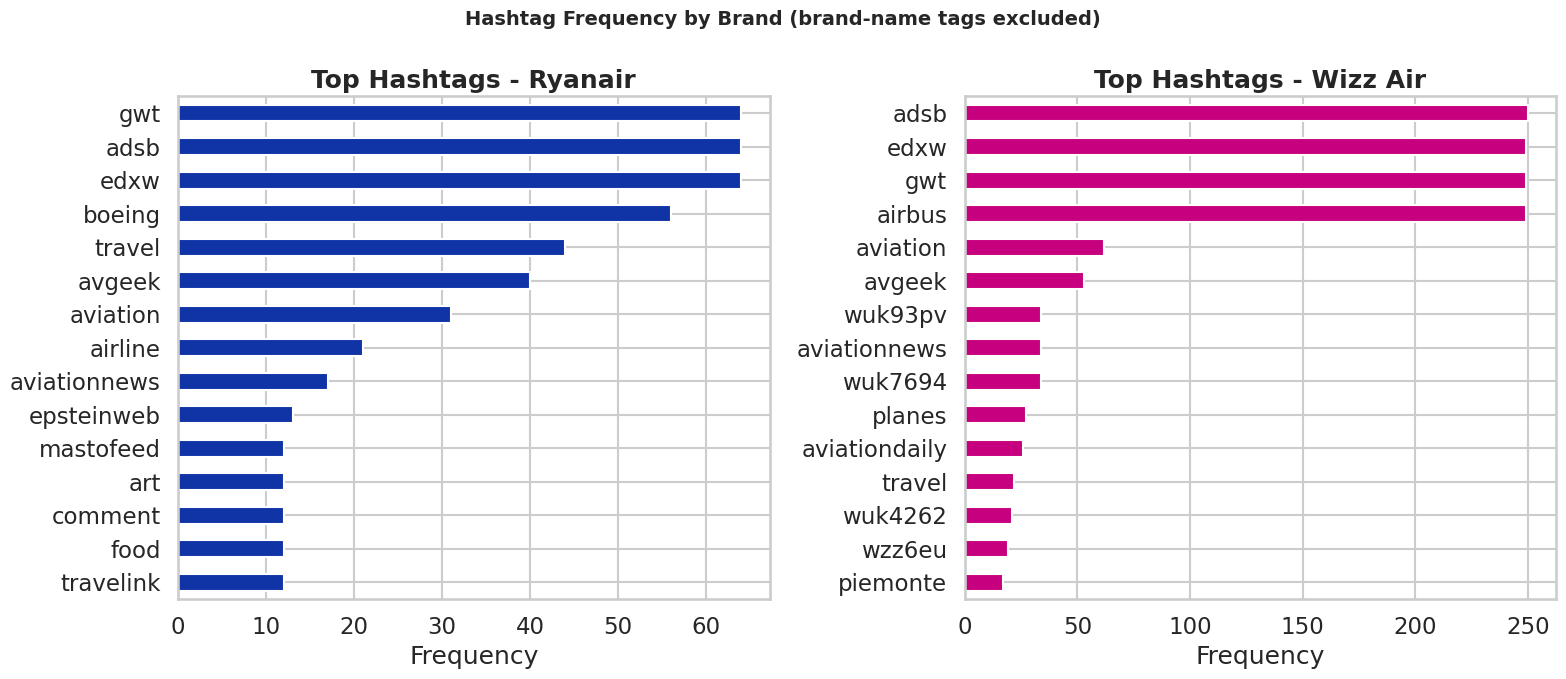


Top 10 hashtags per brand:

Ryanair:
hashtag
ryanair         104
adsb             64
edxw             64
gwt              64
boeing           56
travel           44
avgeek           40
aviation         31
airline          21
aviationnews     17

Wizz Air:
hashtag
adsb            250
gwt             249
edxw            249
airbus          249
wizzair          95
aviation         62
avgeek           53
wuk7694          34
wuk93pv          34
aviationnews     34


In [321]:
#HASHTAG ANALYSIS

def extract_hashtags(text):
    """Extract hashtags from text and return them in lowercase."""
    return re.findall(r"#(\w+)", str(text).lower())


# Create hashtag column
df["hashtags"] = df["text"].apply(extract_hashtags)


# Convert hashtags into separate rows for analysis
hashtag_rows = [
    {"brand": row["brand"], "hashtag": hashtag}
    for _, row in df.iterrows()
    for hashtag in row["hashtags"]
]

hashtag_df = pd.DataFrame(hashtag_rows)

print(f"Total hashtag instances: {len(hashtag_df):,}")
print(hashtag_df["brand"].value_counts().to_string())


# Exclude common brand hashtags
exclude_tags = {
    "ryanair",
    "wizzair",
    "wizz",
    "wizzairgroup",
    "ryanairgroup",
    "ryanaire"
}


# Plot top hashtags for each brand
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, brand in zip(axes, ["Ryanair", "Wizz Air"]):
    filtered_tags = hashtag_df[
        (hashtag_df["brand"] == brand) &
        (~hashtag_df["hashtag"].isin(exclude_tags))
    ]

    top_tags = filtered_tags["hashtag"].value_counts().head(15)
    color = RYANAIR_COLOR if brand == "Ryanair" else WIZZAIR_COLOR

    top_tags.plot(kind="barh", ax=ax, color=color)

    ax.invert_yaxis()
    ax.set_title(f"Top Hashtags - {brand}", fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")


plt.suptitle(
    "Hashtag Frequency by Brand (brand-name tags excluded)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# Print top hashtags
print("\nTop 10 hashtags per brand:")

for brand in ["Ryanair", "Wizz Air"]:
    top_tags = (
        hashtag_df[hashtag_df["brand"] == brand]["hashtag"]
        .value_counts()
        .head(10)
    )

    print(f"\n{brand}:\n{top_tags.to_string()}")

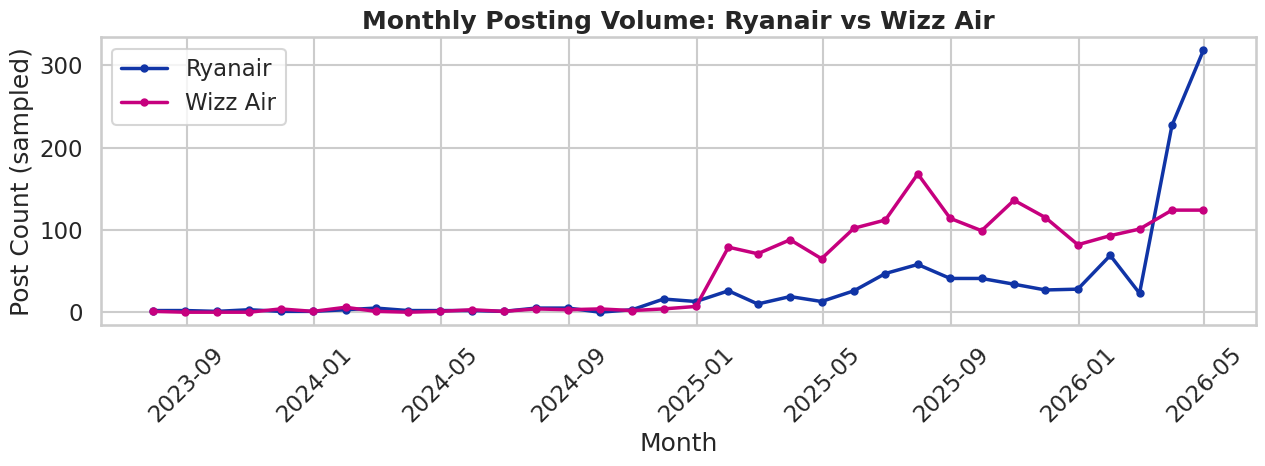

Date range: 2023-07-09 -> 2026-04-30
          count  mean   std  min  25%   50%    75%    max
brand                                                    
Ryanair    34.0  31.6  64.7  0.0  2.0  11.5   27.8  318.0
Wizz Air   34.0  50.4  54.8  0.0  1.2   6.5  100.5  168.0


In [322]:
#MONTHLY POSTING TREND

# Set date column as index for resampling
ts = df.set_index("created_at")

# Count posts per month for each brand
monthly = (
    ts.groupby("brand")
      .resample("ME")["cid"]
      .count()
      .reset_index()
      .rename(columns={
          "cid": "post_count",
          "created_at": "month"
      })
)

# Plot monthly trend
fig, ax = plt.subplots(figsize=(13, 5))

for brand, color in COM_COLORS.items():
    brand_data = monthly[monthly["brand"] == brand]

    ax.plot(
        brand_data["month"],
        brand_data["post_count"],
        label=brand,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=5
    )

ax.set_title("Monthly Posting Volume: Ryanair vs Wizz Air", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Post Count (sampled)")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print(
    "Date range:",
    df["created_at"].min().date(),
    "->",
    df["created_at"].max().date()
)

print(
    monthly.groupby("brand")["post_count"]
    .describe()
    .round(1)
)

# **SECTION E: Sentiment Analysis**
# Measures public opinion using TextBlob and VADER, combines scores, and visualizes sentiment patterns.

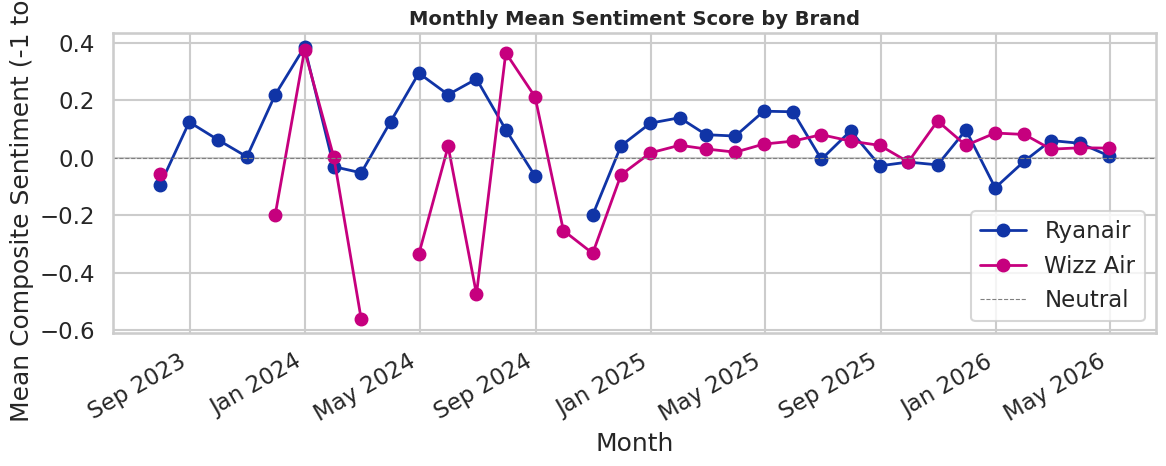

In [323]:
#SENTIMENT OVER TIME

# Calculate monthly average sentiment for each brand
ts_sent = (
    df.set_index("created_at")
      .groupby("brand")
      .resample("ME")["sentiment"]
      .mean()
      .reset_index()
)

# Plot sentiment trend
fig, ax = plt.subplots(figsize=(12, 5))

for brand, brand_data in ts_sent.groupby("brand"):
    ax.plot(
        brand_data["created_at"],
        brand_data["sentiment"],
        marker="o",
        label=brand,
        color=COM_COLORS[brand],
        linewidth=2
    )

# Add neutral reference line
ax.axhline(
    0,
    color="grey",
    linestyle="--",
    linewidth=0.8,
    label="Neutral"
)

ax.set_title("Monthly Mean Sentiment Score by Brand", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Composite Sentiment (-1 to +1)")
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("sentiment_over_time.png", dpi=150)
plt.show()

In [324]:
#TEXTBLOB SENTIMENT

# Calculate TextBlob sentiment scores
df["textblob_sentiment"] = df["text_clean"].apply(
    lambda text: TextBlob(text).sentiment.polarity
)

df["textblob_subjectivity"] = df["text_clean"].apply(
    lambda text: TextBlob(text).sentiment.subjectivity
)

print("TextBlob sentiment computed.")

df[["textblob_sentiment", "textblob_subjectivity"]].describe().round(3)

TextBlob sentiment computed.


,textblob_sentiment,textblob_subjectivity
count,3368.000,3368.000
mean,0.049,0.201
std,0.189,0.273
min,-1.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,0.068,0.400
max,1.000,1.000


In [325]:
#VADER SENTIMENT

def vader_score(text):
    """Return VADER compound sentiment score."""
    return vader.polarity_scores(str(text))["compound"]


# Calculate VADER sentiment
df["vader_sentiment"] = df["text_clean"].apply(vader_score)

print("VADER sentiment computed.")

df["vader_sentiment"].describe().round(3)

VADER sentiment computed.


,vader_sentiment
count,3368.000
mean,0.031
std,0.345
min,-0.962
25%,0.000
50%,0.000
75%,0.103
max,0.978


In [326]:
#COMBINED SENTIMENT SCORE

# Combine TextBlob and VADER scores
df["sentiment"] = (
    df["textblob_sentiment"] + df["vader_sentiment"]
) / 2


# Add sentiment labels
df["sentiment_label"] = pd.cut(
    df["sentiment"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["Negative", "Neutral", "Positive"]
)

print("Sentiment label distribution:")
print(df["sentiment_label"].value_counts().to_string())

print("\nMean sentiment by brand:")
print(
    df.groupby("brand")["sentiment"]
    .mean()
    .round(4)
    .to_string()
)

Sentiment label distribution:
sentiment_label
Neutral     1547
Positive    1137
Negative     684

Mean sentiment by brand:
brand
Ryanair     0.0289
Wizz Air    0.0494


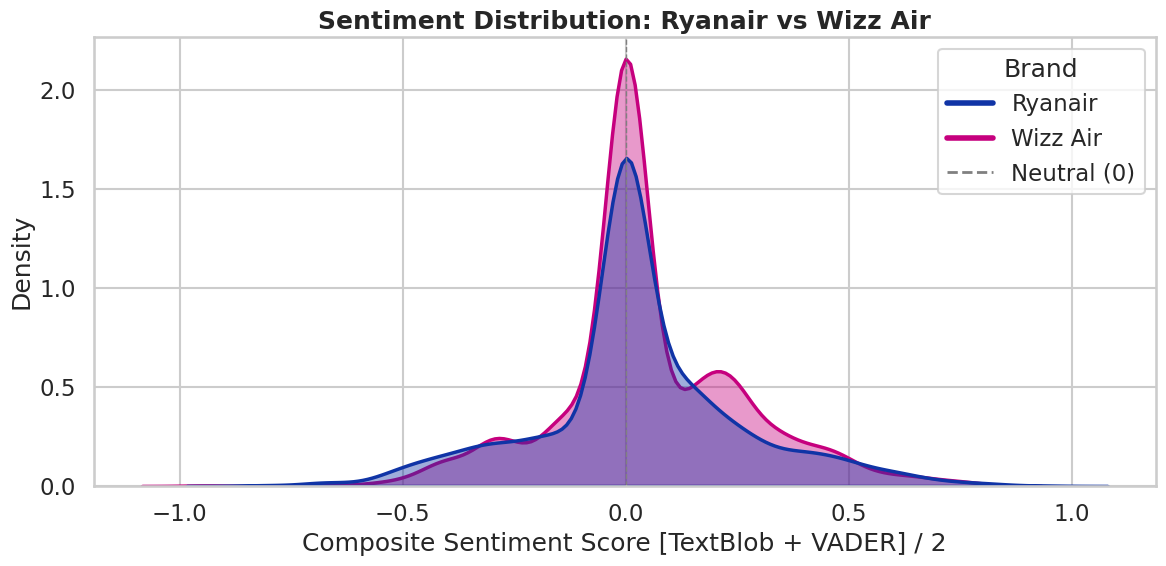

In [332]:
# SENTIMENT DISTRIBUTION

import matplotlib.lines as mlines

# Plot sentiment distribution for both brands
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=df,
    x="sentiment",
    hue="brand",
    fill=True,
    alpha=0.40,
    linewidth=2.5,
    palette=COM_COLORS,
    ax=ax
)

# Neutral reference line
ax.axvline(
    0,
    color="grey",
    linestyle="--",
    linewidth=1
)

# Custom legend with brand colours
legend_handles = [
    mlines.Line2D([], [], color=COM_COLORS["Ryanair"], lw=4, label="Ryanair"),
    mlines.Line2D([], [], color=COM_COLORS["Wizz Air"], lw=4, label="Wizz Air"),
    mlines.Line2D([], [], color="grey", linestyle="--", lw=2, label="Neutral (0)")
]

ax.legend(
    handles=legend_handles,
    title="Brand",
    frameon=True
)

ax.set_title("Sentiment Distribution: Ryanair vs Wizz Air", fontweight="bold")
ax.set_xlabel("Composite Sentiment Score [TextBlob + VADER] / 2")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

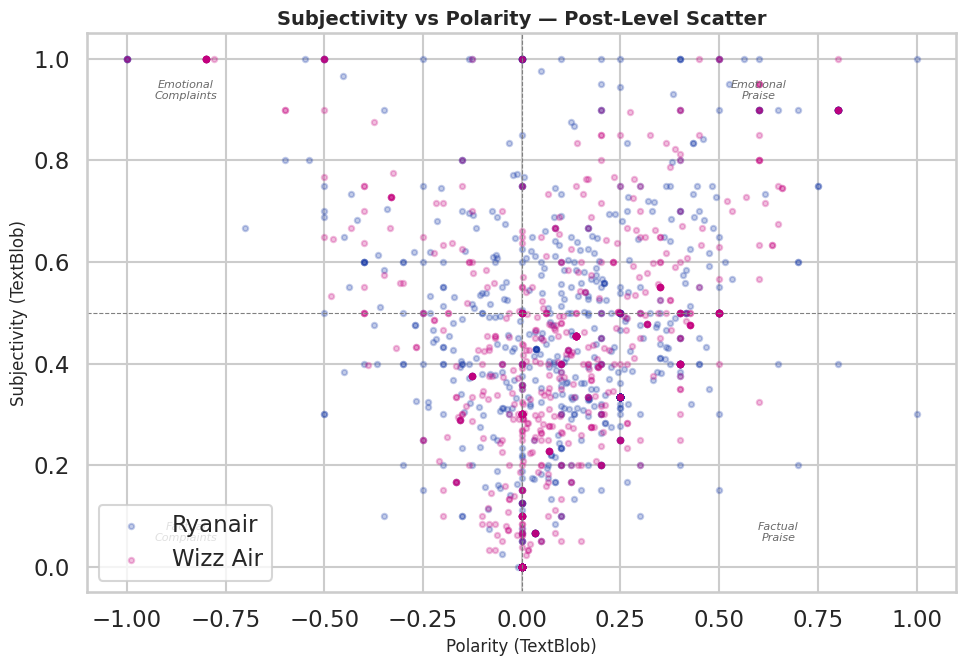

In [328]:
#SUBJECTIVITY vs POLARITY SCATTER

# Plot polarity vs subjectivity for each post
fig, ax = plt.subplots(figsize=(10, 7))

for brand, brand_data in df.groupby("brand"):
    ax.scatter(
        brand_data["textblob_sentiment"],
        brand_data["textblob_subjectivity"],
        alpha=0.25,
        s=15,
        label=brand,
        color=COM_COLORS[brand]
    )

# Reference lines
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle="--")

ax.set_xlabel("Polarity (TextBlob)", fontsize=12)
ax.set_ylabel("Subjectivity (TextBlob)", fontsize=12)
ax.set_title(
    "Subjectivity vs Polarity — Post-Level Scatter",
    fontsize=14,
    fontweight="bold"
)

ax.legend()


# Add quadrant labels
quadrant_labels = [
    (-0.85, 0.92, "Emotional\nComplaints"),
    (0.60, 0.92, "Emotional\nPraise"),
    (-0.85, 0.05, "Factual\nComplaints"),
    (0.65, 0.05, "Factual\nPraise")
]

for x, y, label in quadrant_labels:
    ax.text(
        x,
        y,
        label,
        fontsize=8,
        color="dimgrey",
        ha="center",
        style="italic"
    )

plt.tight_layout()
plt.savefig("subjectivity_polarity_scatter.png", dpi=150)
plt.show()

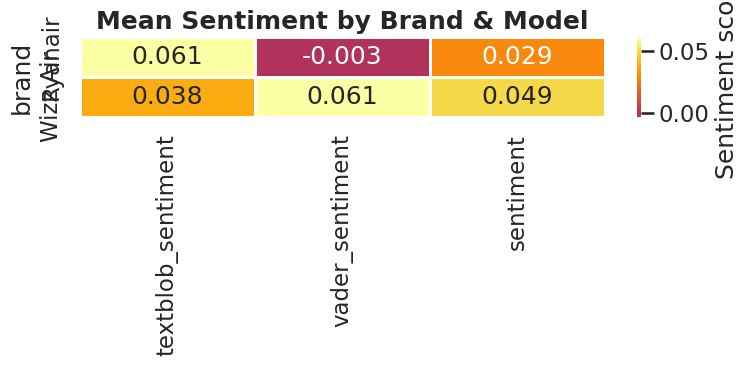

          textblob_sentiment  vader_sentiment  sentiment
brand                                                   
Ryanair                0.061           -0.003      0.029
Wizz Air               0.038            0.061      0.049


In [329]:
#MEAN SENTIMENT HEATMAP

# Calculate average sentiment scores for each brand
heat = (
    df.groupby("brand")[[
        "textblob_sentiment",
        "vader_sentiment",
        "sentiment"
    ]]
    .mean()
    .round(3)
)

# Plot heatmap
plt.figure(figsize=(8, 4))

sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    cmap="inferno",
    center=0,
    linewidths=1,
    cbar_kws={"label": "Sentiment score"}
)

plt.title("Mean Sentiment by Brand & Model", fontweight="bold")
plt.tight_layout()
plt.show()

print(heat.to_string())

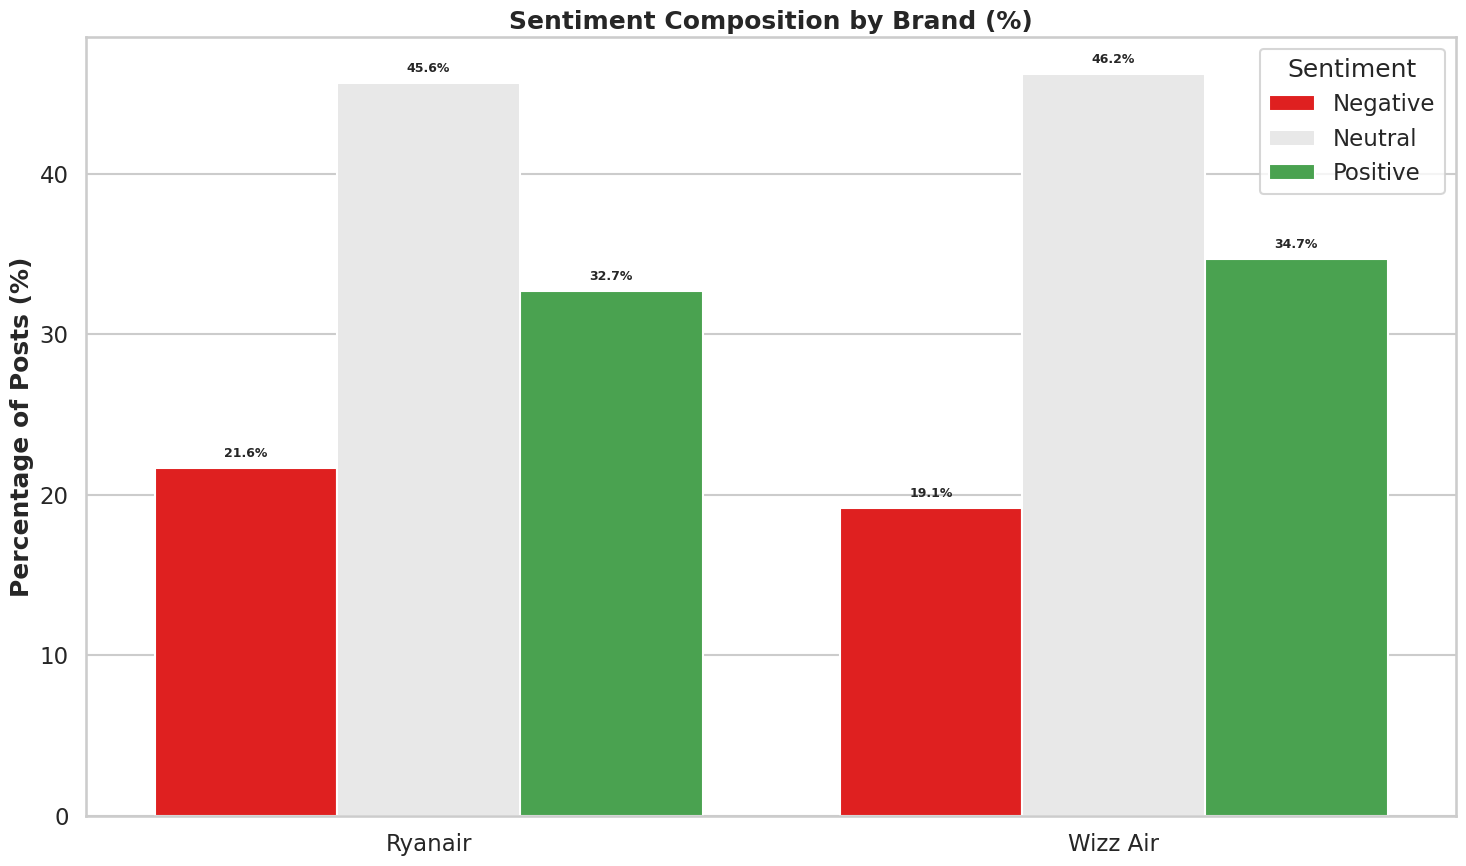

   brand sentiment_label       pct
 Ryanair        Negative 21.642266
 Ryanair         Neutral 45.639720
 Ryanair        Positive 32.718014
Wizz Air        Negative 19.143016
Wizz Air         Neutral 46.188091
Wizz Air        Positive 34.668893


In [330]:
#SENTIMENT COMPOSITION BY BRAND

# Count sentiment labels for each brand
mix = (
    df.groupby(["brand", "sentiment_label"])
      .size()
      .reset_index(name="count")
)

# Convert counts to percentages
mix["pct"] = mix.groupby("brand")["count"].transform(
    lambda values: values / values.sum() * 100
)

# Plot sentiment breakdown
fig, ax = plt.subplots(figsize=(15, 9))

sns.barplot(
    data=mix,
    x="brand",
    y="pct",
    hue="sentiment_label",
    palette={
        "Negative": "#FF0000",
        "Neutral": "#E8E8E8",
        "Positive": "#3BB143"
    },
    ax=ax
)

ax.set_title("Sentiment Composition by Brand (%)", fontweight="bold")
ax.set_ylabel("Percentage of Posts (%)", fontweight="bold")
ax.set_xlabel("", fontweight="bold")
ax.legend(title="Sentiment")


# Add percentage labels on bars
for bar in ax.patches:
    height = bar.get_height()

    if height > 1:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

print(mix[["brand", "sentiment_label", "pct"]].to_string(index=False))

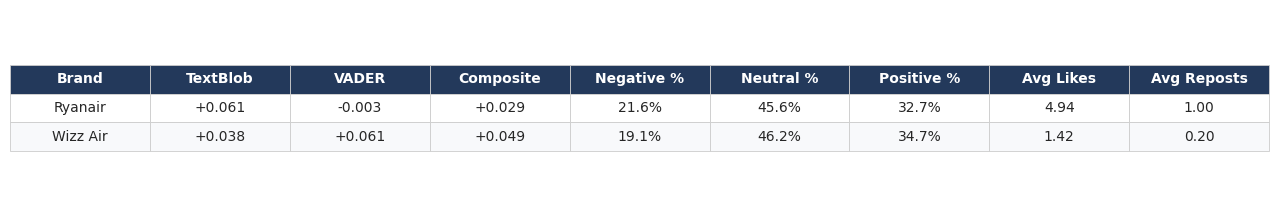

In [413]:
# Brand-level averages
summary = df.groupby("brand").agg(
    TextBlob=("textblob_sentiment", "mean"),
    VADER=("vader_sentiment", "mean"),
    Composite=("sentiment", "mean"),
    Avg_Likes=("like_count", "mean"),
    Avg_Reposts=("repost_count", "mean")
)

# Sentiment split %
sentiment_split = (
    df.groupby(["brand", "sentiment_label"])
      .size()
      .unstack(fill_value=0)
)

sentiment_split = sentiment_split.div(
    sentiment_split.sum(axis=1), axis=0
) * 100

# Final table
final = pd.DataFrame({
    "Brand": summary.index,
    "TextBlob": summary["TextBlob"].apply(lambda x: f"{x:+.3f}"),
    "VADER": summary["VADER"].apply(lambda x: f"{x:+.3f}"),
    "Composite": summary["Composite"].apply(lambda x: f"{x:+.3f}"),
    "Negative %": sentiment_split["Negative"].apply(lambda x: f"{x:.1f}%"),
    "Neutral %": sentiment_split["Neutral"].apply(lambda x: f"{x:.1f}%"),
    "Positive %": sentiment_split["Positive"].apply(lambda x: f"{x:.1f}%"),
    "Avg Likes": summary["Avg_Likes"].apply(lambda x: f"{x:.2f}"),
    "Avg Reposts": summary["Avg_Reposts"].apply(lambda x: f"{x:.2f}")
}).reset_index(drop=True)


fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis("off")

table = ax.table(
    cellText=final.values,
    colLabels=final.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.7)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#CCCCCC")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#23395B")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F8F9FB" if row % 2 == 0 else "#FFFFFF")

plt.tight_layout()
plt.savefig("brand_summary.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# **SECTION F: Topic Modelling & Discussion Themes**
# Uses LDA and BERTopic to uncover the main conversation themes around each airline.

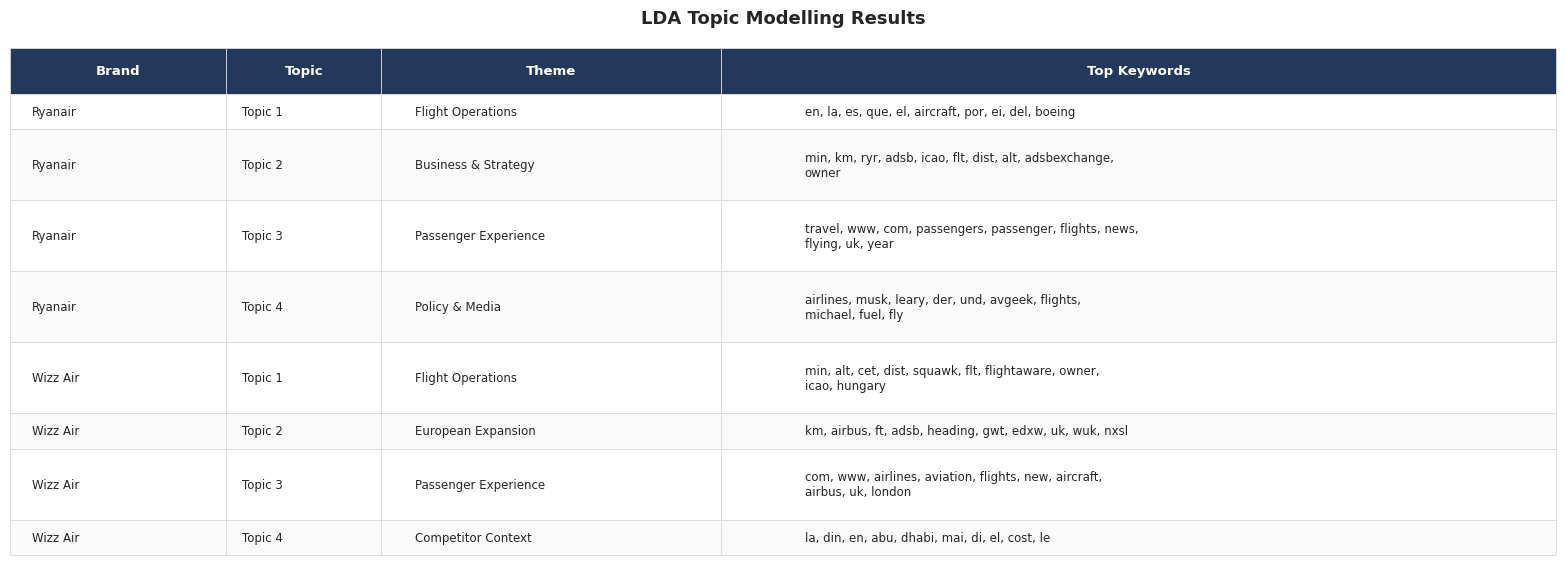

In [415]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

rows = []

for brand in ["Ryanair", "Wizz Air"]:

    subset = df.loc[df["brand"] == brand, "text_clean"]

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=10,
        max_df=0.85
    )

    X = vectorizer.fit_transform(subset)

    vocab = np.array(vectorizer.get_feature_names_out())
    keep = [i for i, word in enumerate(vocab) if word not in CUSTOM_STOP]

    X = X[:, keep]
    vocab = vocab[keep]

    lda = LatentDirichletAllocation(
        n_components=4,
        random_state=42,
        max_iter=20,
        learning_method="batch"
    )

    lda.fit(X)

    for i, topic in enumerate(lda.components_):
        words = vocab[np.argsort(topic)[-10:]][::-1]

        rows.append([
            brand,
            f"Topic {i+1}",
            TOPIC_LABELS[brand][i],
            "\n".join(textwrap.wrap(", ".join(words), width=55))
        ])

topic_df = pd.DataFrame(
    rows,
    columns=["Brand", "Topic", "Theme", "Top Keywords"]
)

# ---------- Image ----------
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis("off")

table = ax.table(
    cellText=topic_df.values,
    colLabels=topic_df.columns,
    colWidths=[0.14, 0.10, 0.22, 0.54],
    cellLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.7)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D9D9D9")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#23395B")
        cell.set_text_props(color="white", weight="bold", fontsize=9.5)
        cell.set_height(0.09)

    else:
        cell.set_facecolor("#FAFAFA" if row % 2 == 0 else "#FFFFFF")
        cell.set_text_props(fontsize=8.5)

        # auto row height
        lines = str(topic_df.iloc[row-1, 3]).count("\n") + 1
        cell.set_height(0.07 * max(lines, 1))

plt.title(
    "LDA Topic Modelling Results",
    fontsize=13,
    fontweight="bold",
    pad=18
)

plt.tight_layout()
plt.savefig("lda_topics_sleek.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

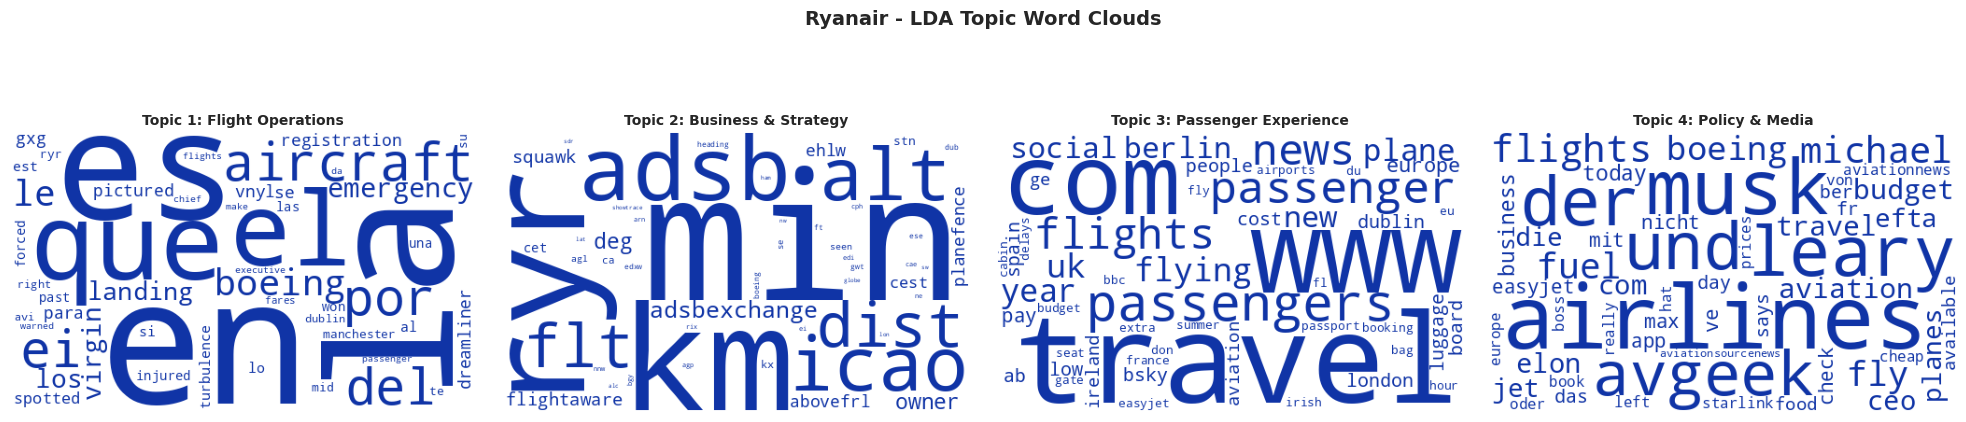

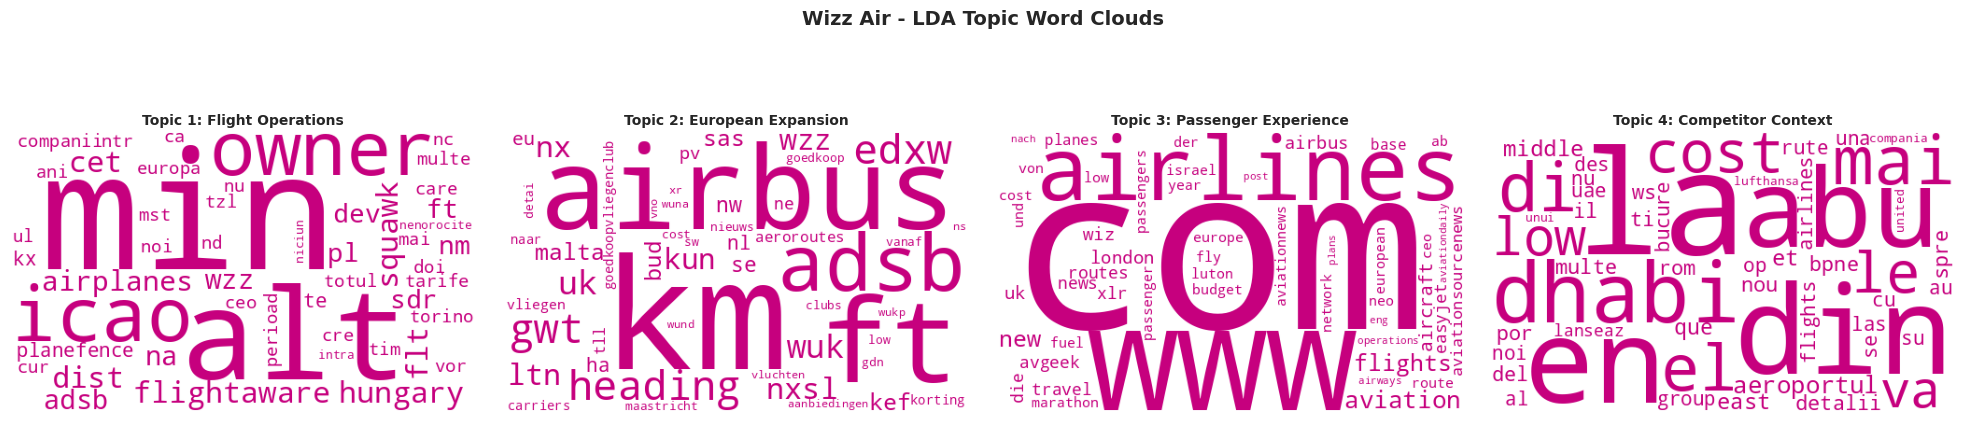

In [400]:
# LDA TOPIC WORD CLOUDS

from wordcloud import WordCloud

for brand in ["Ryanair", "Wizz Air"]:
    text = df.loc[df["brand"] == brand, "text_clean"]

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=10,
        max_df=0.85
    )

    X = vectorizer.fit_transform(text)
    vocab = np.array(vectorizer.get_feature_names_out())

    keep = [i for i, word in enumerate(vocab) if word not in CUSTOM_STOP]
    X, vocab = X[:, keep], vocab[keep]

    lda = LatentDirichletAllocation(
        n_components=4,
        random_state=42,
        max_iter=20,
        learning_method="batch"
    ).fit(X)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for i, (ax, topic) in enumerate(zip(axes, lda.components_)):
        word_freq = {vocab[j]: topic[j] for j in topic.argsort()[-50:]}

        wc = WordCloud(
            width=500,
            height=300,
            background_color="white",
            color_func=lambda *args, **kwargs: BRAND_COLORS[brand],
            collocations=False
        ).generate_from_frequencies(word_freq)

        ax.imshow(wc)
        ax.axis("off")
        ax.set_title(
            f"Topic {i+1}: {TOPIC_LABELS[brand][i]}",
            fontsize=10,
            fontweight="bold"
        )

    plt.suptitle(
        f"{brand} - LDA Topic Word Clouds",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

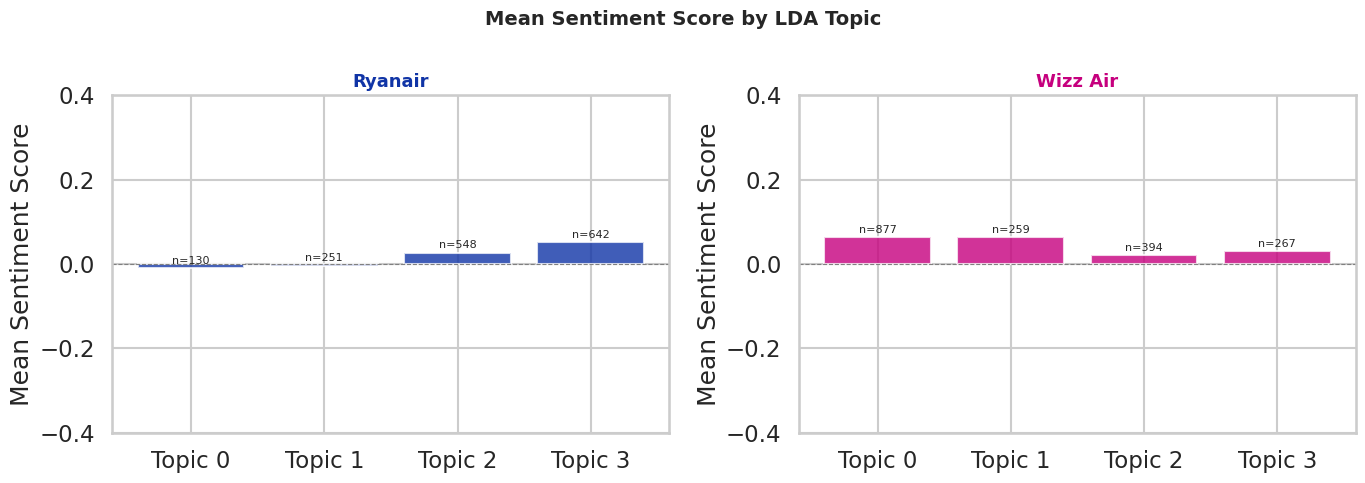

In [333]:
#MEAN SENTIMENT BY LDA TOPIC

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


CUSTOM_STOP = {
    "flight", "airline", "airport", "ryanair", "wizzair", "wizz", "air",
    "just", "like", "get", "one", "go", "know", "good", "time", "now", "also",
    "will", "can", "said", "say", "would", "got", "going", "want", "need"
}


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, brand in zip(axes, ["Ryanair", "Wizz Air"]):
    brand_data = df[df["brand"] == brand].copy()

    # Create text matrix
    vectorizer = CountVectorizer(
        max_features=1000,
        min_df=5,
        max_df=0.85,
        stop_words="english",
        ngram_range=(1, 1)
    )

    X = vectorizer.fit_transform(
        brand_data["text_clean"].fillna("")
    )

    # Train LDA model
    lda = LatentDirichletAllocation(
        n_components=4,
        random_state=42,
        max_iter=20,
        learning_method="online"
    )

    lda.fit(X)

    # Assign dominant topic to each post
    brand_data["lda_topic"] = lda.transform(X).argmax(axis=1)

    topic_sentiment = (
        brand_data.groupby("lda_topic")["sentiment"]
                  .agg(["mean", "count"])
                  .reset_index()
    )

    # Plot average sentiment by topic
    bars = ax.bar(
        [f"Topic {topic}" for topic in topic_sentiment["lda_topic"]],
        topic_sentiment["mean"],
        color=COM_COLORS[brand],
        alpha=0.8,
        edgecolor="white"
    )

    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(
        brand,
        fontsize=13,
        fontweight="bold",
        color=COM_COLORS[brand]
    )
    ax.set_ylabel("Mean Sentiment Score")
    ax.set_ylim(-0.4, 0.4)

    # Add sample size labels
    for bar, (_, row) in zip(bars, topic_sentiment.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"n={int(row['count'])}",
            ha="center",
            fontsize=8
        )

fig.suptitle("Mean Sentiment Score by LDA Topic", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("sentiment_by_topic.png", dpi=150)
plt.show()

In [334]:
#BERTOPIC TOPIC MODELLING

# Words to remove from noisy posts
NOISE_WORDS = {
    "adsb", "icao", "km", "edxw", "gwt", "heading", "photo", "jetphotos",
    "keyword", "airbus", "boeing", "ctrl", "linktr", "https", "www", "com",
    "globe", "nxsl", "efta", "ryr", "wzz", "wuk", "xlr", "sas", "nl", "nx",
    "aviation", "airport", "airports"
}

# Words that indicate telemetry / tracking posts
NOISE_TRIGGERS = [
    "adsb",
    "airbus",
    "boeing",
    "edxw",
    "gwt",
    "ryr",
    "wuk"
]


docs = []

for text in df["text_clean"]:
    words = text.split()

    # Skip noisy tracking posts
    if any(word in words for word in NOISE_TRIGGERS):
        continue

    # Keep only meaningful words
    filtered_words = [
        word
        for word in words
        if word not in NOISE_WORDS
        and len(word) > 3
        and not word.isnumeric()
    ]

    if len(filtered_words) >= 5:
        docs.append(" ".join(filtered_words))


# Sample data for faster processing
sample_docs = (
    pd.Series(docs)
      .sample(min(1000, len(docs)), random_state=42)
      .tolist()
)

print(f"Documents passed to BERTopic: {len(sample_docs):,}")


# Train BERTopic model
topic_model = BERTopic(
    verbose=False,
    min_topic_size=50
)

topics, probs = topic_model.fit_transform(sample_docs)

topic_info = topic_model.get_topic_info()

print(f"\nTopics found (excluding outlier -1): {len(topic_info) - 1}")
print(topic_info[["Topic", "Count", "Name"]].to_string(index=False))

Documents passed to BERTopic: 1,000


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Topics found (excluding outlier -1): 4
 Topic  Count                          Name
    -1     56          -1_adsb_edxw_gwt_wzz
     0    305 0_ryanair_flight_airline_from
     1    300     1_wizz_ryanair_multe_care
     2    260      2_wizz_from_flights_with
     3     79        3_adsb_edxw_gwt_airbus


# **SECTION G: Keyword & Text Analysis**
# Extracts keywords and visualizes common terms through frequency charts, networks, and word clouds.

In [335]:
#KEYWORD EXTRACTION

KEYWORD_STOP = {
    "https", "www", "com", "adsb", "icao", "km", "edxw", "gwt", "ft", "fi",
    "heading", "photo", "globe", "jetphotos", "keyword", "airbus", "boeing",
    "ryr", "wzz", "ctrl", "linktr", "consulta", "plataforma", "redes"
}


def extract_keywords(text):
    """Extract meaningful words from cleaned text."""
    words = []

    for word in str(text).lower().split():
        word = word.replace("#", "")

        # Skip short or noisy words
        if len(word) <= 4:
            continue

        if word in KEYWORD_STOP:
            continue

        words.append(word)

    return words


# Create keywords column
df["keywords"] = df["text_clean"].apply(extract_keywords)

keyword_count_total = df["keywords"].apply(len).sum()

print(f"Keywords extracted - total tokens across all posts: {keyword_count_total:,}")

df["keywords"].head(4)

Keywords extracted - total tokens across all posts: 32,131


,keywords
0,"[social, social, scrivo, capite, almeno, scors..."
1,"[guerra, ryanair, contra, saliendo, rentable, ..."
2,[ryanair]
3,"[would, ryanair, follow, until, forced]"


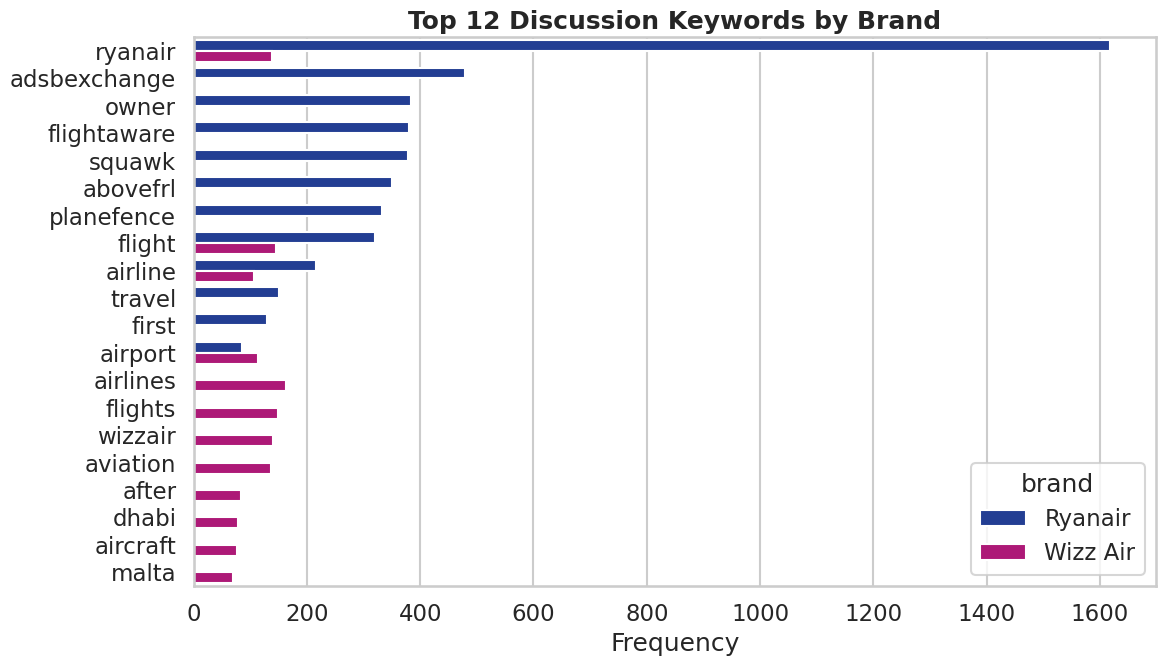

In [336]:
#TOP KEYWORDS BY BRAND

rows = []

for brand in ["Ryanair", "Wizz Air"]:
    all_words = [
        word
        for keyword_list in df.loc[df["brand"] == brand, "keywords"]
        for word in keyword_list
    ]

    for word, count in Counter(all_words).most_common(12):
        rows.append({
            "brand": brand,
            "keyword": word,
            "count": count
        })


kw_df = pd.DataFrame(rows)


# Plot top keywords
plt.figure(figsize=(12, 7))

sns.barplot(
    data=kw_df,
    x="count",
    y="keyword",
    hue="brand",
    palette=COM_COLORS
)

plt.title("Top 12 Discussion Keywords by Brand", fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("")

plt.tight_layout()
plt.show()

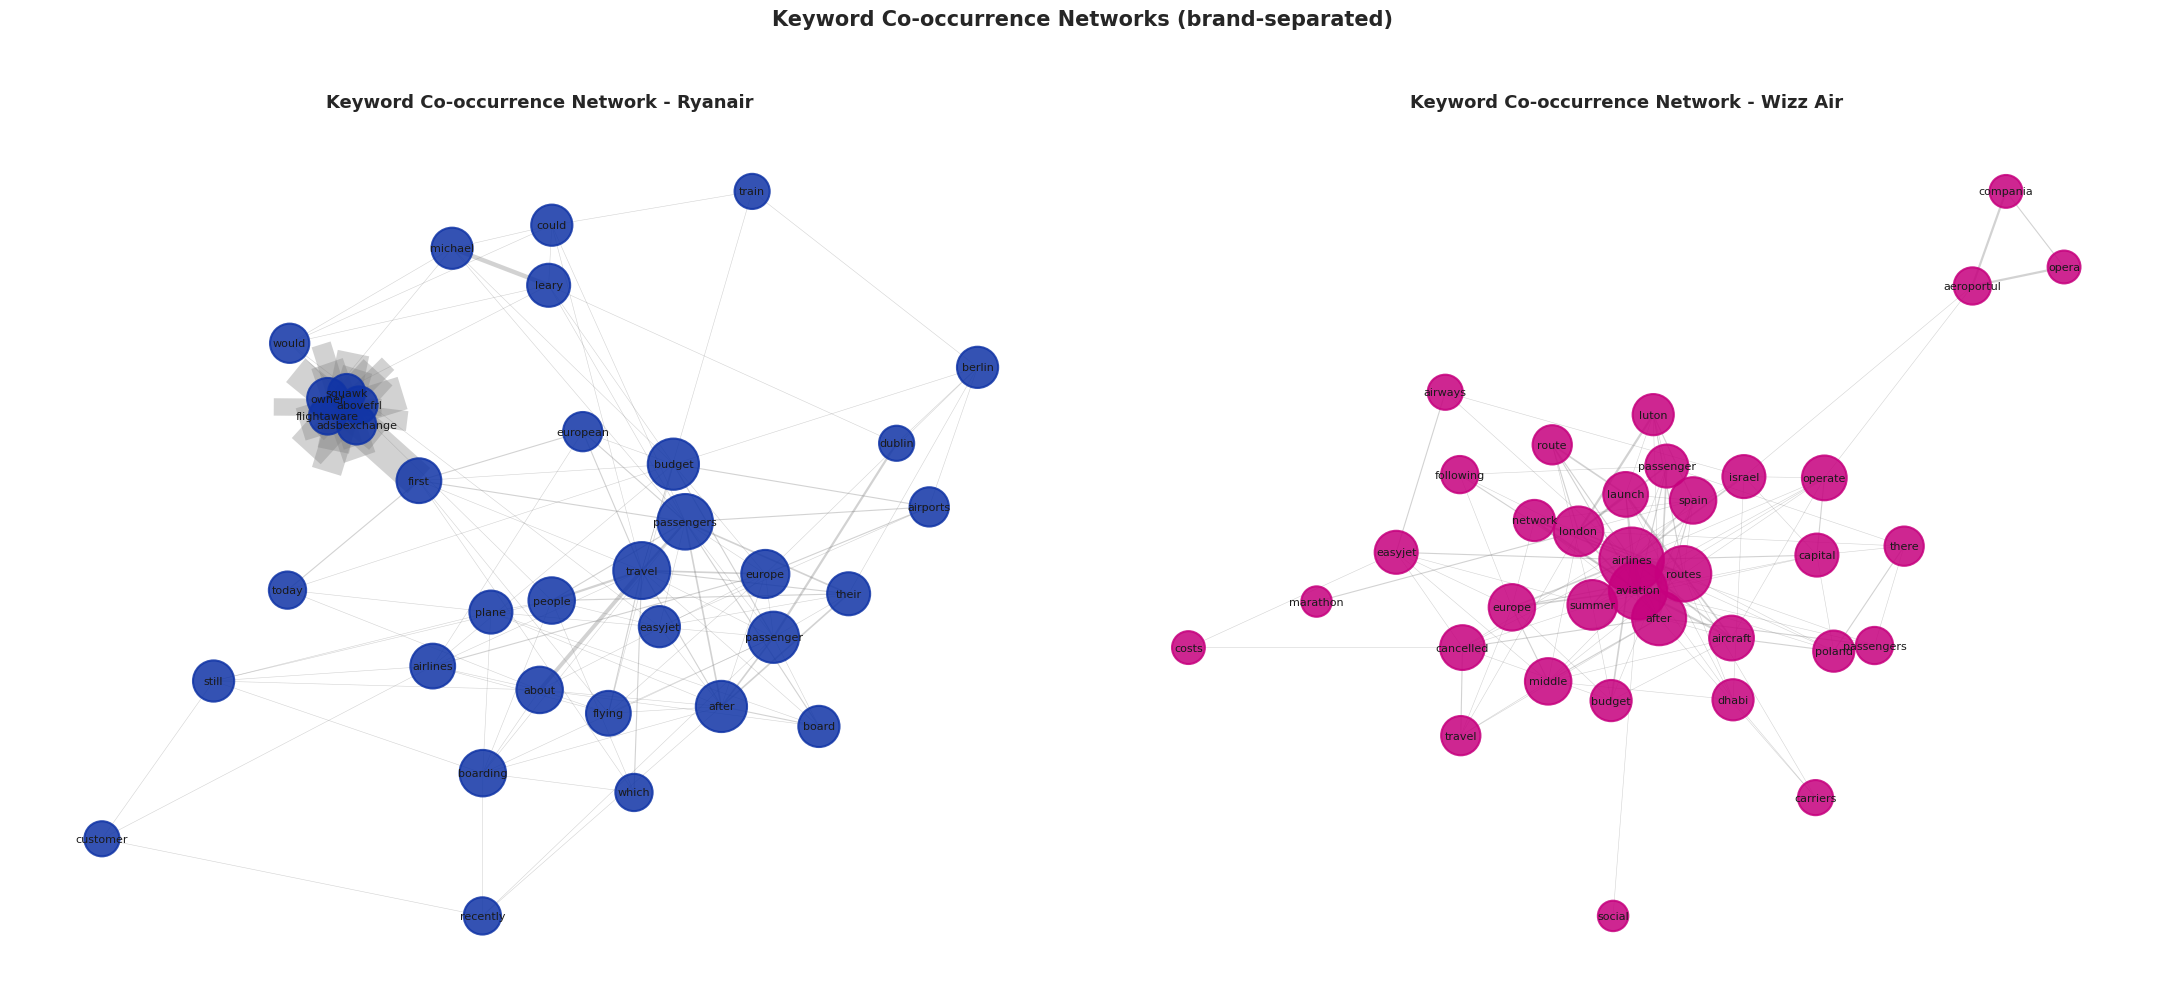

In [337]:
#KEYWORD CO-OCCURRENCE NETWORK

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Words to exclude from the network
EXCLUDE_NETWORK = {
    "ryanair",
    "wizzair",
    "wizz",
    "flight",
    "airline",
    "airport",
    "flights"
}

for ax, brand in zip(axes, ["Ryanair", "Wizz Air"]):

    G = nx.Graph()

    brand_data = df[df["brand"] == brand].sample(
        min(800, len(df[df["brand"] == brand])),
        random_state=42
    )

    # Build keyword connections
    for keywords in brand_data["keywords"]:
        tokens = list(set([
            word for word in keywords[:8]
            if word not in EXCLUDE_NETWORK
        ]))

        for i in range(len(tokens)):
            for j in range(i + 1, len(tokens)):
                word1, word2 = tokens[i], tokens[j]

                if G.has_edge(word1, word2):
                    G[word1][word2]["weight"] += 1
                else:
                    G.add_edge(word1, word2, weight=1)

    # Keep top connected nodes
    top_nodes = [
        node
        for node, _ in sorted(
            G.degree,
            key=lambda item: item[1],
            reverse=True
        )[:35]
    ]

    H = G.subgraph(top_nodes)
    pos = nx.spring_layout(H, seed=42, k=0.7)

    # Node size based on connectivity
    degrees = dict(H.degree())
    node_sizes = [
        400 + degrees[node] * 80
        for node in H.nodes()
    ]

    # Edge width based on connection strength
    edge_widths = [
        H[node1][node2]["weight"] * 0.4
        for node1, node2 in H.edges()
    ]

    color = RYANAIR_COLOR if brand == "Ryanair" else WIZZAIR_COLOR

    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=node_sizes,
        node_color=color,
        alpha=0.85,
        ax=ax
    )

    nx.draw_networkx_edges(
        H,
        pos,
        width=edge_widths,
        alpha=0.35,
        edge_color="grey",
        ax=ax
    )

    nx.draw_networkx_labels(
        H,
        pos,
        font_size=8,
        ax=ax
    )

    ax.set_title(
        f"Keyword Co-occurrence Network - {brand}",
        fontweight="bold",
        fontsize=13
    )

    ax.axis("off")


plt.suptitle(
    "Keyword Co-occurrence Networks (brand-separated)",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

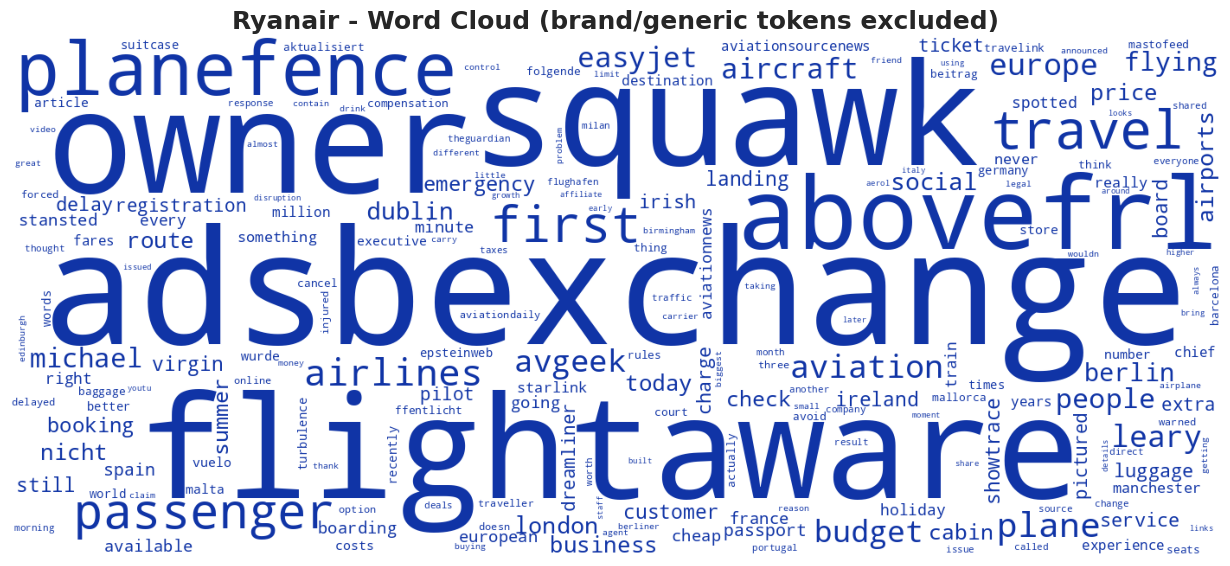

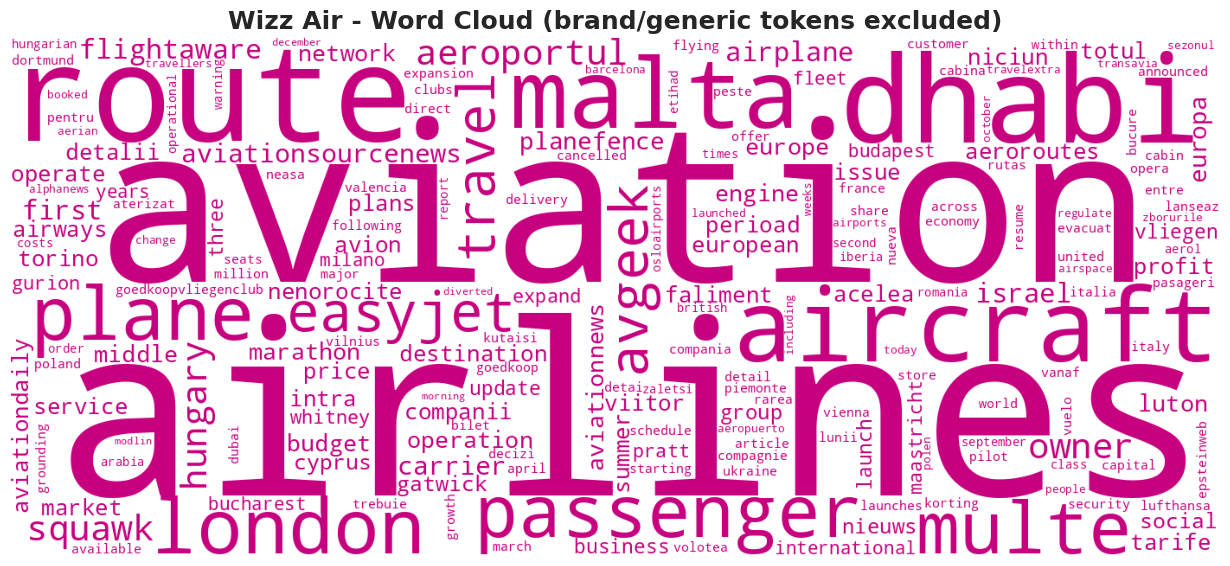

In [338]:
#WORD CLOUDS

# Words to exclude from the word cloud
EXCLUDE_CLOUD = {
    "ryanair",
    "wizz",
    "wizzair",
    "flight",
    "airline",
    "airport",
    "flights"
}

for brand in ["Ryanair", "Wizz Air"]:
    all_words = [
        word
        for keyword_list in df.loc[df["brand"] == brand, "keywords"]
        for word in keyword_list
        if word not in EXCLUDE_CLOUD
    ]

    text = " ".join(all_words)

    color = RYANAIR_COLOR if brand == "Ryanair" else WIZZAIR_COLOR

    # Create word cloud
    wc = WordCloud(
        width=1400,
        height=600,
        background_color="white",
        color_func=lambda *args, **kwargs: color,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(
        f"{brand} - Word Cloud (brand/generic tokens excluded)",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# **SECTION H: Consumer Positioning Analysis**
# Builds a perceptual map to compare how both brands are positioned in public discussion.

PC1 explains 8.5% of variance
  + pole: min, icao, dist, flt, alt, adsbexchange
  - pole: air, wizz, flight
PC2 explains 4.9% of variance
  + pole: km, edxw, gwt, heading, ft, airbus
  - pole: ryanair, flight, airline


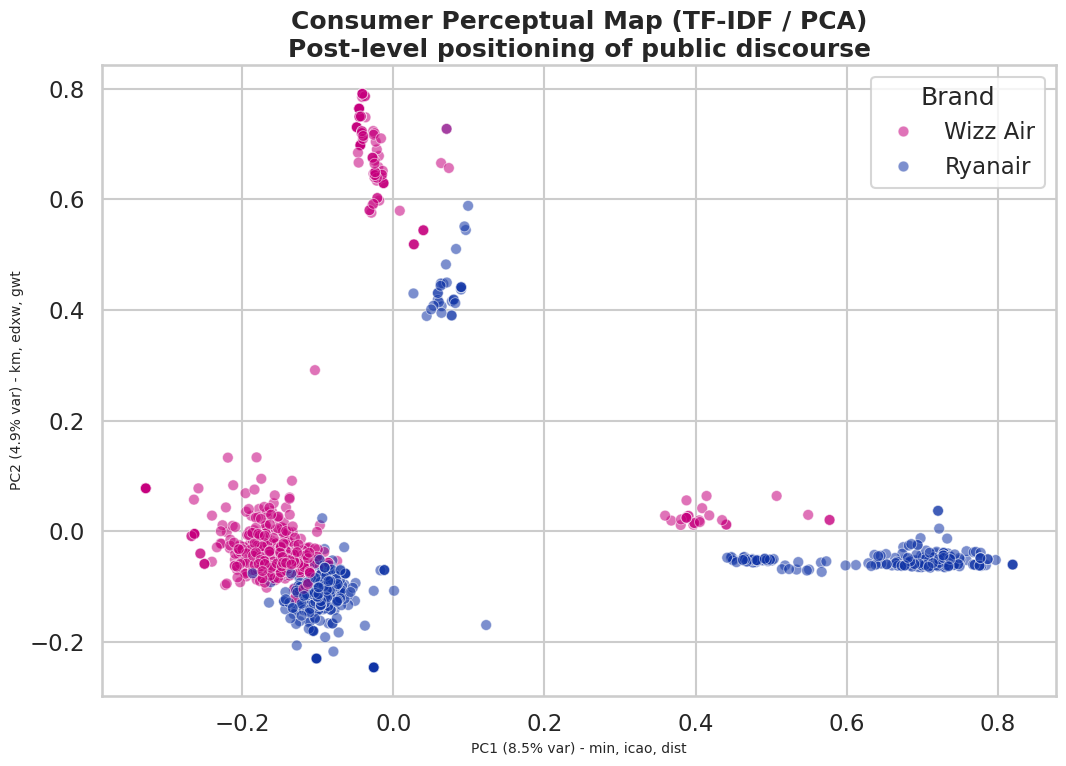

In [339]:
#TF-IDF PCA PERCEPTUAL MAP

# Sample posts
sample = df.sample(min(1500, len(df)), random_state=42).copy()


# Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=500
)

X = tfidf.fit_transform(sample["text_clean"])


# Reduce features to 2 dimensions
pca = PCA(
    n_components=2,
    random_state=42
)

coords = pca.fit_transform(X.toarray())


# Get important terms for each PCA axis
feature_names = np.array(tfidf.get_feature_names_out())

pc1_pos_terms = feature_names[np.argsort(pca.components_[0])[-6:]][::-1]
pc1_neg_terms = feature_names[np.argsort(pca.components_[0])[:3]]

pc2_pos_terms = feature_names[np.argsort(pca.components_[1])[-6:]][::-1]
pc2_neg_terms = feature_names[np.argsort(pca.components_[1])[:3]]


print(f"PC1 explains {pca.explained_variance_ratio_[0] * 100:.1f}% of variance")
print(f"  + pole: {', '.join(pc1_pos_terms)}")
print(f"  - pole: {', '.join(pc1_neg_terms)}")

print(f"PC2 explains {pca.explained_variance_ratio_[1] * 100:.1f}% of variance")
print(f"  + pole: {', '.join(pc2_pos_terms)}")
print(f"  - pole: {', '.join(pc2_neg_terms)}")


# Prepare data for plotting
plot_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "brand": sample["brand"].values
})


# Plot perceptual map
fig, ax = plt.subplots(figsize=(11, 8))

sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="brand",
    alpha=0.55,
    s=60,
    palette=COM_COLORS,
    ax=ax
)

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var) - "
    f"{', '.join(pc1_pos_terms[:3])}",
    fontsize=10
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var) - "
    f"{', '.join(pc2_pos_terms[:3])}",
    fontsize=10
)

ax.set_title(
    "Consumer Perceptual Map (TF-IDF / PCA)\n"
    "Post-level positioning of public discourse",
    fontweight="bold"
)

ax.legend(title="Brand")

plt.tight_layout()
plt.show()

# **SECTION I: Audience Segmentation**
# Clusters users into engagement groups (high, medium, low) based on interaction behaviour.

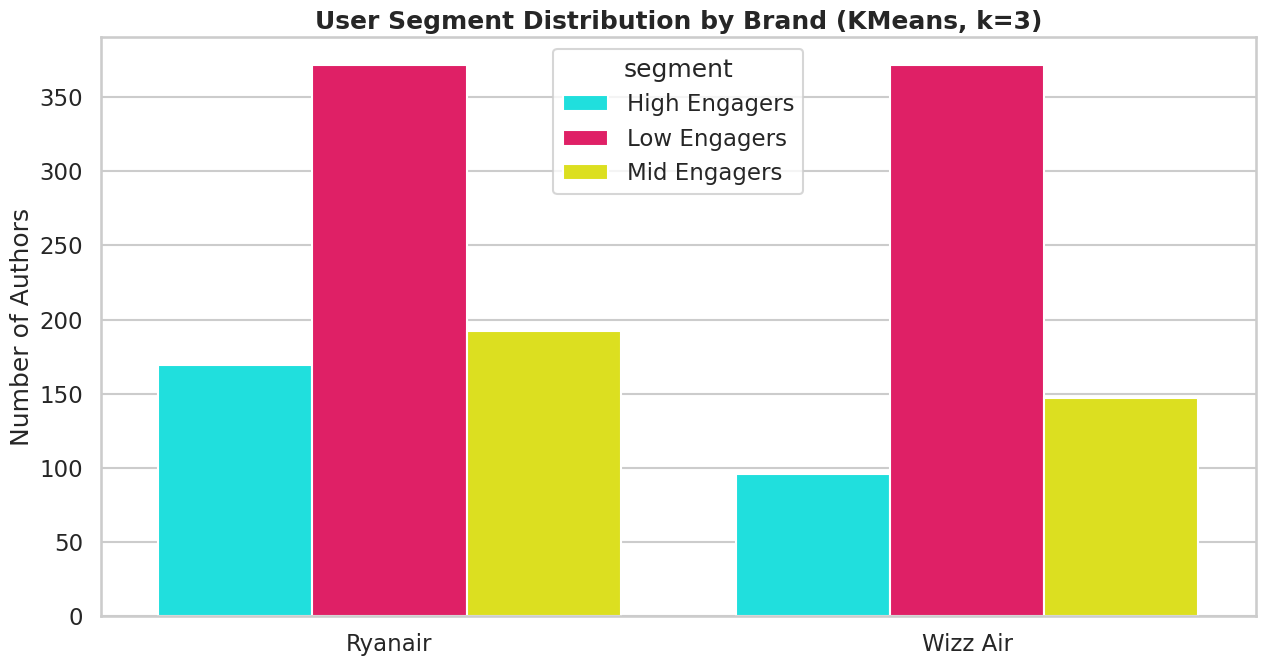

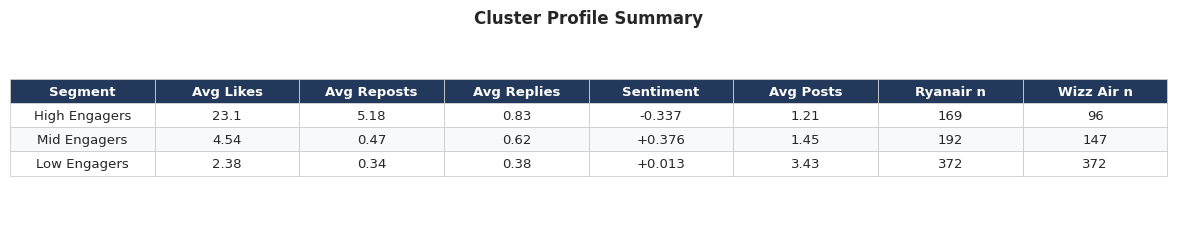

In [420]:
#USER SEGMENTATION

# USER SEGMENTATION

# Aggregate author-level engagement
cluster_agg = (
    df.groupby(["brand", "author"])
      .agg(
          likes=("like_count", "mean"),
          reposts=("repost_count", "mean"),
          replies=("reply_count", "mean"),
          sentiment=("sentiment", "mean"),
          posts=("cid", "count")
      )
      .reset_index()
)

CLUSTER_FEATS = ["likes", "reposts", "replies", "sentiment"]

# Scale features
scaler = MinMaxScaler()
X_cluster = scaler.fit_transform(
    cluster_agg[CLUSTER_FEATS].fillna(0)
)

# Run KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_agg["cluster"] = kmeans.fit_predict(X_cluster)

# Label clusters
engagement_mean = (
    cluster_agg.groupby("cluster")[["likes", "reposts"]]
               .mean()
               .sum(axis=1)
)

CLUSTER_MAP = {
    engagement_mean.idxmax(): "High Engagers",
    engagement_mean.idxmin(): "Low Engagers"
}

for cluster in cluster_agg["cluster"].unique():
    if cluster not in CLUSTER_MAP:
        CLUSTER_MAP[cluster] = "Mid Engagers"

cluster_agg["segment"] = cluster_agg["cluster"].map(CLUSTER_MAP)

# Count segments by brand
seg_counts = (
    cluster_agg.groupby(["brand", "segment"])
               .size()
               .reset_index(name="count")
)

# ORIGINAL GRAPH (unchanged)
plt.figure(figsize=(13, 7))

sns.barplot(
    data=seg_counts,
    x="brand",
    y="count",
    hue="segment",
    palette={
        "High Engagers": "#00FFFC",
        "Mid Engagers": "#FBFF00",
        "Low Engagers": "#FF005D"
    }
)

plt.title("User Segment Distribution by Brand (KMeans, k=3)", fontweight="bold")
plt.ylabel("Number of Authors")
plt.xlabel("")

plt.tight_layout()
plt.show()


# -------- Summary Table --------
segment_order = ["High Engagers", "Mid Engagers", "Low Engagers"]

cluster_profile = (
    cluster_agg.groupby("segment")
    .agg(
        **{
            "Avg Likes": ("likes", "mean"),
            "Avg Reposts": ("reposts", "mean"),
            "Avg Replies": ("replies", "mean"),
            "Sentiment": ("sentiment", "mean"),
            "Avg Posts": ("posts", "mean")
        }
    )
    .reindex(segment_order)
)

segment_counts = (
    cluster_agg.groupby(["segment", "brand"])
    .size()
    .unstack(fill_value=0)
    .reindex(segment_order)
)

summary_table = (
    cluster_profile
    .join(segment_counts)
    .reset_index()
    .rename(columns={
        "segment": "Segment",
        "Ryanair": "Ryanair n",
        "Wizz Air": "Wizz Air n"
    })
)

summary_table["Avg Likes"] = summary_table["Avg Likes"].round(2)
summary_table["Avg Reposts"] = summary_table["Avg Reposts"].round(2)
summary_table["Avg Replies"] = summary_table["Avg Replies"].round(2)
summary_table["Avg Posts"] = summary_table["Avg Posts"].round(2)
summary_table["Sentiment"] = summary_table["Sentiment"].map(lambda x: f"{x:+.3f}")

# TABLE IMAGE
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.15, 1.65)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#CCCCCC")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#23395B")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F8F9FB" if row % 2 == 0 else "#FFFFFF")

plt.title(
    "Cluster Profile Summary",
    fontsize=12,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.savefig("cluster_profile_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# **SECTION J: Author Profiling & Enrichment**
# Fetches profile details, calculates posting frequency, and builds richer author-level metrics.

In [341]:
#PROFILE FETCH FUNCTION

def fetch_profile(handle):
    """Fetch profile stats for a BlueSky user."""
    try:
        response = requests.get(
            f"{BASE_URL}/app.bsky.actor.getProfile",
            params={"actor": handle},
            headers=HEADERS,
            timeout=20
        )

        if response.status_code != 200:
            return {
                "followers": np.nan,
                "following": np.nan,
                "posts": np.nan
            }

        data = response.json()

        return {
            "followers": data.get("followersCount", np.nan),
            "following": data.get("followsCount", np.nan),
            "posts": data.get("postsCount", np.nan)
        }

    except Exception:
        return {
            "followers": np.nan,
            "following": np.nan,
            "posts": np.nan
        }

In [342]:
#AUTHOR ENGAGEMENT METRICS

# Calculate engagement metrics for each author
author_metrics = (
    df.groupby(["brand", "author"], as_index=False)
      .agg(
          posts=("cid", "count"),
          likes=("like_count", "mean"),
          reposts=("repost_count", "mean"),
          replies=("reply_count", "mean"),
          sentiment=("sentiment", "mean")
      )
)


# Create engagement score
author_metrics["engagement"] = (
    author_metrics["likes"]
    + author_metrics["reposts"] * 2
    + author_metrics["replies"]
)

print(f"Author metrics computed - {len(author_metrics):,} author-brand pairs")

author_metrics.head()

Author metrics computed - 1,348 author-brand pairs


,brand,author,posts,likes,reposts,replies,sentiment,engagement
0,Ryanair,20minutos.es,1,2.000000,0.0,0.000000,0.000000,2.000000
1,Ryanair,4lau.bsky.social,6,0.000000,0.0,0.000000,-0.299700,0.000000
2,Ryanair,abc.es,1,0.000000,0.0,0.000000,0.000000,0.000000
3,Ryanair,abovearth.bsky.social,128,0.007812,0.0,0.007812,0.106141,0.015625
4,Ryanair,aboveedxw.de,64,0.000000,0.0,0.000000,0.002486,0.000000


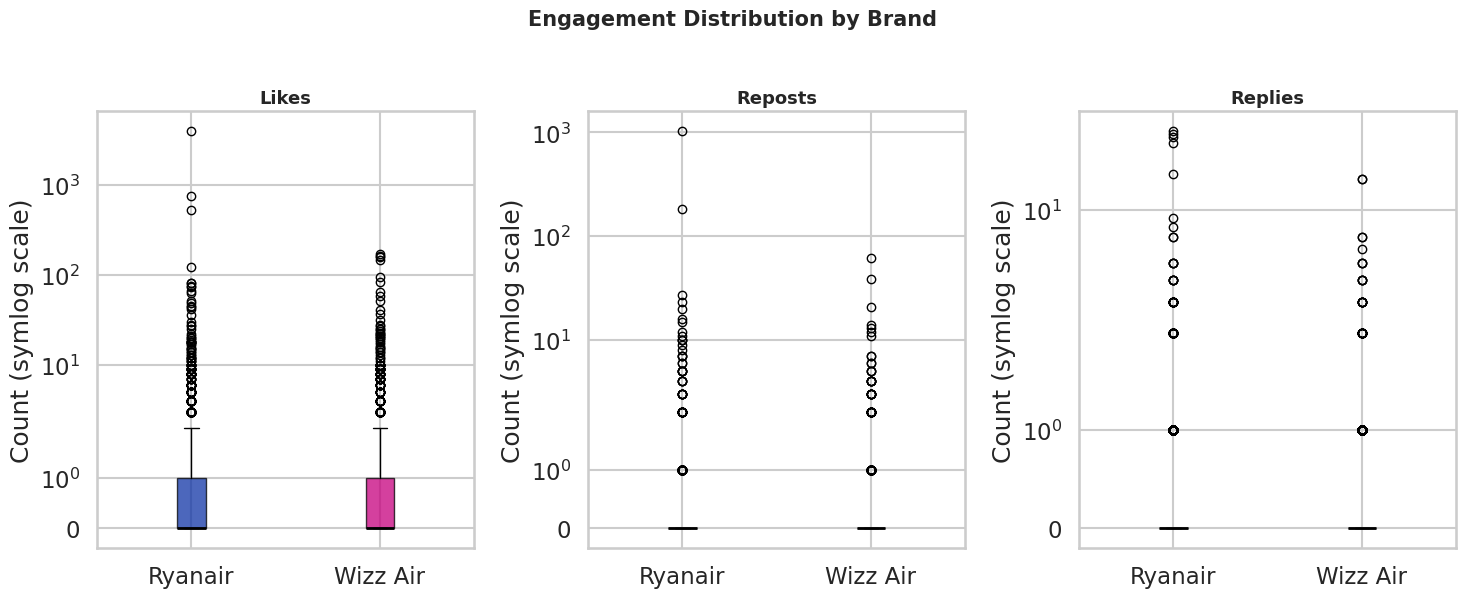

In [343]:
#ENGAGEMENT DISTRIBUTION

metrics = ["like_count", "repost_count", "reply_count"]
labels = ["Likes", "Reposts", "Replies"]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, column, label in zip(axes, metrics, labels):
    data = [
        df[df["brand"] == brand][column].clip(lower=0)
        for brand in ["Ryanair", "Wizz Air"]
    ]

    boxplot = ax.boxplot(
        data,
        patch_artist=True,
        notch=False,
        medianprops={
            "color": "black",
            "linewidth": 2
        }
    )

    for patch, color in zip(
        boxplot["boxes"],
        [RYANAIR_COLOR, WIZZAIR_COLOR]
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_yscale("symlog")
    ax.set_xticklabels(["Ryanair", "Wizz Air"])
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count (symlog scale)")

fig.suptitle(
    "Engagement Distribution by Brand",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.savefig("engagement_boxplots.png", dpi=150)
plt.show()

In [344]:
#FETCH PROFILE DATA

unique_authors = author_metrics["author"].unique()
profiles = {}

for i, handle in enumerate(unique_authors):
    if i % 50 == 0:
        print(f"{i} / {len(unique_authors)} profiles fetched...")

    profiles[handle] = fetch_profile(handle)

    time.sleep(0.10)


# Convert profile data into a DataFrame
profile_df = (
    pd.DataFrame(profiles)
      .T
      .reset_index()
      .rename(columns={"index": "author"})
)

print(f"\nProfiles fetched: {len(profile_df):,}")

profile_df.head()

0 / 1240 profiles fetched...
50 / 1240 profiles fetched...
100 / 1240 profiles fetched...
150 / 1240 profiles fetched...
200 / 1240 profiles fetched...
250 / 1240 profiles fetched...
300 / 1240 profiles fetched...
350 / 1240 profiles fetched...
400 / 1240 profiles fetched...
450 / 1240 profiles fetched...
500 / 1240 profiles fetched...
550 / 1240 profiles fetched...
600 / 1240 profiles fetched...
650 / 1240 profiles fetched...
700 / 1240 profiles fetched...
750 / 1240 profiles fetched...
800 / 1240 profiles fetched...
850 / 1240 profiles fetched...
900 / 1240 profiles fetched...
950 / 1240 profiles fetched...
1000 / 1240 profiles fetched...
1050 / 1240 profiles fetched...
1100 / 1240 profiles fetched...
1150 / 1240 profiles fetched...
1200 / 1240 profiles fetched...

Profiles fetched: 1,240


,author,followers,following,posts
0,20minutos.es,17324,4908,25074
1,4lau.bsky.social,37,1,4071
2,abc.es,914,1,50704
3,abovearth.bsky.social,94,181,38840
4,aboveedxw.de,163,24,119343


In [345]:
#MERGE PROFILE DATA

# Remove old profile columns if they already exist
DROP_COLS = [
    "followers",
    "following",
    "posts_total",
    "posts_x",
    "posts_y",
    "followers_x",
    "followers_y",
    "following_x",
    "following_y"
]

author_metrics = author_metrics.drop(
    columns=[col for col in DROP_COLS if col in author_metrics.columns],
    errors="ignore"
)


# Rename profile posts column
profile_df = profile_df.rename(columns={"posts": "profile_posts"})


# Merge profile data
author_metrics = author_metrics.merge(
    profile_df,
    on="author",
    how="left"
)


# Convert profile columns to numeric
for column, new_name in [
    ("followers", "followers"),
    ("following", "following"),
    ("profile_posts", "posts_total")
]:
    author_metrics[new_name] = pd.to_numeric(
        author_metrics[column],
        errors="coerce"
    ).fillna(0)

    if new_name != column:
        author_metrics["posts_total"] = (
            author_metrics.pop("posts_total")
            if "posts_total" in author_metrics.columns
            else 0
        )


author_metrics["posts_total"] = pd.to_numeric(
    author_metrics["profile_posts"],
    errors="coerce"
).fillna(0)


print(f"Profile data merged - {len(author_metrics):,} rows")

author_metrics[
    [
        "brand",
        "author",
        "posts",
        "followers",
        "following",
        "posts_total",
        "engagement",
        "sentiment"
    ]
].head()

Profile data merged - 1,348 rows


,brand,author,posts,followers,following,posts_total,engagement,sentiment
0,Ryanair,20minutos.es,1,17324,4908,25074,2.000000,0.000000
1,Ryanair,4lau.bsky.social,6,37,1,4071,0.000000,-0.299700
2,Ryanair,abc.es,1,914,1,50704,0.000000,0.000000
3,Ryanair,abovearth.bsky.social,128,94,181,38840,0.015625,0.106141
4,Ryanair,aboveedxw.de,64,163,24,119343,0.000000,0.002486


In [346]:
#POSTING FREQUENCY

# Calculate posting activity for each author
activity = (
    df.groupby(["brand", "author"])["created_at"]
      .agg(["min", "max", "count"])
      .reset_index()
)

# Number of active days
activity["days_active"] = (
    activity["max"] - activity["min"]
).dt.days + 1

activity["days_active"] = activity["days_active"].clip(lower=1)

# Posts per day
activity["posting_frequency"] = (
    activity["count"] / activity["days_active"]
)

print("Posting frequency computed.")

activity[
    [
        "brand",
        "author",
        "count",
        "days_active",
        "posting_frequency"
    ]
].head()

Posting frequency computed.


,brand,author,count,days_active,posting_frequency
0,Ryanair,20minutos.es,1,1.0,1.000000
1,Ryanair,4lau.bsky.social,6,45.0,0.133333
2,Ryanair,abc.es,1,1.0,1.000000
3,Ryanair,abovearth.bsky.social,0,NaN,NaN
4,Ryanair,aboveedxw.de,64,53.0,1.207547


In [347]:
#MERGE ACTIVITY METRICS

# Add posting frequency to author metrics
author_metrics = author_metrics.merge(
    activity[["brand", "author", "posting_frequency"]],
    on=["brand", "author"],
    how="left"
)

print("Activity metrics merged.")
print(f"Columns: {list(author_metrics.columns)}")

Activity metrics merged.
Columns: ['brand', 'author', 'posts', 'likes', 'reposts', 'replies', 'sentiment', 'engagement', 'followers', 'following', 'profile_posts', 'posts_total', 'posting_frequency']


# **SECTION K: Network Analysis**
# Measures how central each author is in brand-related conversations using keyword-sharing networks.

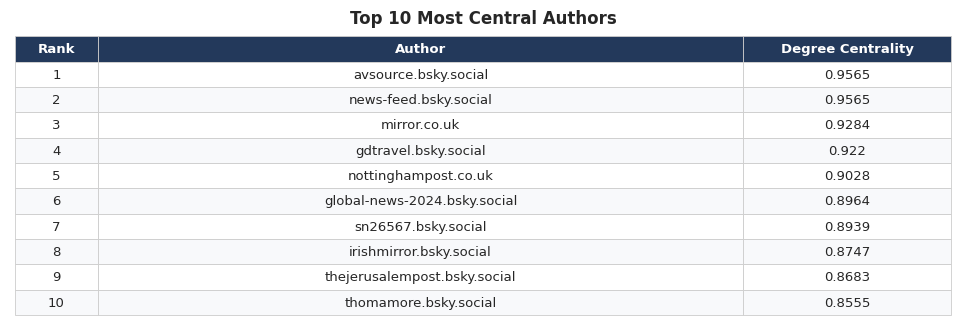

In [425]:
# TOP 10 CENTRAL AUTHORS (IMAGE ONLY)

top10 = centrality_df.head(10).copy()

top10["Rank"] = range(1, len(top10) + 1)
top10["centrality"] = top10["centrality"].round(4)

top10 = top10[
    ["Rank", "author", "centrality"]
].rename(columns={
    "author": "Author",
    "centrality": "Degree Centrality"
})

# ----- Create image -----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.axis("off")

table = ax.table(
    cellText=top10.values,
    colLabels=top10.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.08, 0.62, 0.20]
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.1, 1.55)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#CCCCCC")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#23395B")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F8F9FB" if row % 2 == 0 else "#FFFFFF")

plt.title(
    "Top 10 Most Central Authors",
    fontsize=12,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.savefig(
    "top_central_authors.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [349]:
#MERGE CENTRALITY

# Add centrality scores to author metrics
author_metrics = author_metrics.merge(
    centrality_df,
    on="author",
    how="left"
)

author_metrics["centrality"] = author_metrics["centrality"].fillna(0)

print("Centrality merged.")
print(
    f"Centrality range: "
    f"[{author_metrics['centrality'].min():.4f}, "
    f"{author_metrics['centrality'].max():.4f}]"
)

Centrality merged.
Centrality range: [0.0000, 0.9565]


# **SECTION L: Micro-Influencer Identification**
# Filters suitable creators and ranks them using a weighted influencer scoring model.

In [350]:
#FILTER MICRO-INFLUENCER CANDIDATES

# Remove non-personal / unwanted accounts
BAD_ACCOUNT_PATTERNS = [
    ".com", ".org", ".de", "news", "guardian", "times", "post",
    "mastodon", "brid.gy", "invalid", "ukraine", "review", "engineer",
    "capital", "bbc", "cnn", "media", "press", "official", "alert", "bot"
]

mask = ~author_metrics["author"].str.lower().str.contains(
    "|".join(map(re.escape, BAD_ACCOUNT_PATTERNS)),
    na=False
)

author_metrics = author_metrics[mask]


# Keep only micro-influencer follower range
author_metrics = author_metrics[
    (author_metrics["followers"] >= 500) &
    (author_metrics["followers"] <= 50000)
]

print(f"Micro-influencer candidate pool: {len(author_metrics):,} authors")
print(author_metrics["brand"].value_counts().to_string())

Micro-influencer candidate pool: 537 authors
brand
Ryanair     329
Wizz Air    208


In [351]:
print([c for c in author_metrics.columns if 'post' in c.lower() or 'freq' in c.lower()])

['posts', 'reposts', 'profile_posts', 'posts_total', 'posting_frequency']


In [380]:
#COMPOSITE INFLUENCER SCORE

from sklearn.preprocessing import MinMaxScaler


# Fix duplicate column names
author_metrics = author_metrics.drop(
    columns=["posting_frequency_y"],
    errors="ignore"
)

author_metrics = author_metrics.rename(
    columns={"posting_frequency_x": "posting_frequency"},
    errors="ignore"
)

author_metrics["engagement_rate"] = np.log1p(
    author_metrics["engagement"] /
    author_metrics["followers"].clip(lower=1)
)

SCORE_COLS = [
    "followers",
    "engagement_rate",
    "sentiment",
    "posting_frequency",
    "centrality"
]

WEIGHTS = {
    "followers": 0.20,
    "engagement_rate": 0.35,
    "sentiment": 0.20,
    "posting_frequency": 0.15,
    "centrality": 0.10
}

# Check required columns
missing_cols = [
    col for col in SCORE_COLS
    if col not in author_metrics.columns
]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")


# Normalize values
scaler = MinMaxScaler()

norm_cols = [f"{col}_norm" for col in SCORE_COLS]

author_metrics[norm_cols] = scaler.fit_transform(
    author_metrics[SCORE_COLS]
)


# Weights
WEIGHTS = {
    "followers": 0.30,
    "engagement": 0.25,
    "sentiment": 0.20,
    "posting_frequency": 0.15,
    "centrality": 0.10
}


# Calculate final score
author_metrics["influencer_score"] = sum(
    author_metrics[f"{col}_norm"] * weight
    for col, weight in WEIGHTS.items()
)


# Sort by score
author_metrics = (
    author_metrics
    .sort_values("influencer_score", ascending=False)
    .reset_index(drop=True)
)

print("Influencer scores computed.")
print(f"Candidates scored: {len(author_metrics)}")
print(
    f"Score range: "
    f"{author_metrics['influencer_score'].min():.4f} – "
    f"{author_metrics['influencer_score'].max():.4f}"
)

author_metrics[
    [
        "brand",
        "author",
        "followers",
        "engagement",
        "sentiment",
        "centrality",
        "influencer_score"
    ]
].head(10)

Influencer scores computed.
Candidates scored: 537
Score range: 0.0521 – 0.5381


,brand,author,followers,engagement,sentiment,centrality,influencer_score
0,Wizz Air,margareterosali.bsky.social,45296,9.0,0.167517,0.601023,0.538102
1,Ryanair,garius.bsky.social,29784,24.0,0.446217,0.374680,0.446159
2,Ryanair,mredbyrne.bsky.social,21734,121.0,0.476609,0.566496,0.420784
3,Ryanair,planeyboys.bsky.social,4182,6082.0,-0.190900,0.156010,0.418483
4,Wizz Air,shipwreck75.bsky.social,22579,22.5,0.121400,0.466752,0.416178
5,Ryanair,henrik270864.bsky.social,30981,12.0,0.060025,0.318414,0.398127
6,Wizz Air,feenavan2099.bsky.social,33868,2.0,-0.141667,0.207161,0.379220
7,Ryanair,lastudiolafayette.bsky.social,26620,18.0,0.023350,0.335038,0.366254
8,Ryanair,twmcltd.bsky.social,16099,64.0,0.421150,0.374680,0.352930
9,Wizz Air,zimmermanv66.bsky.social,26584,1.0,0.000000,0.171355,0.344691


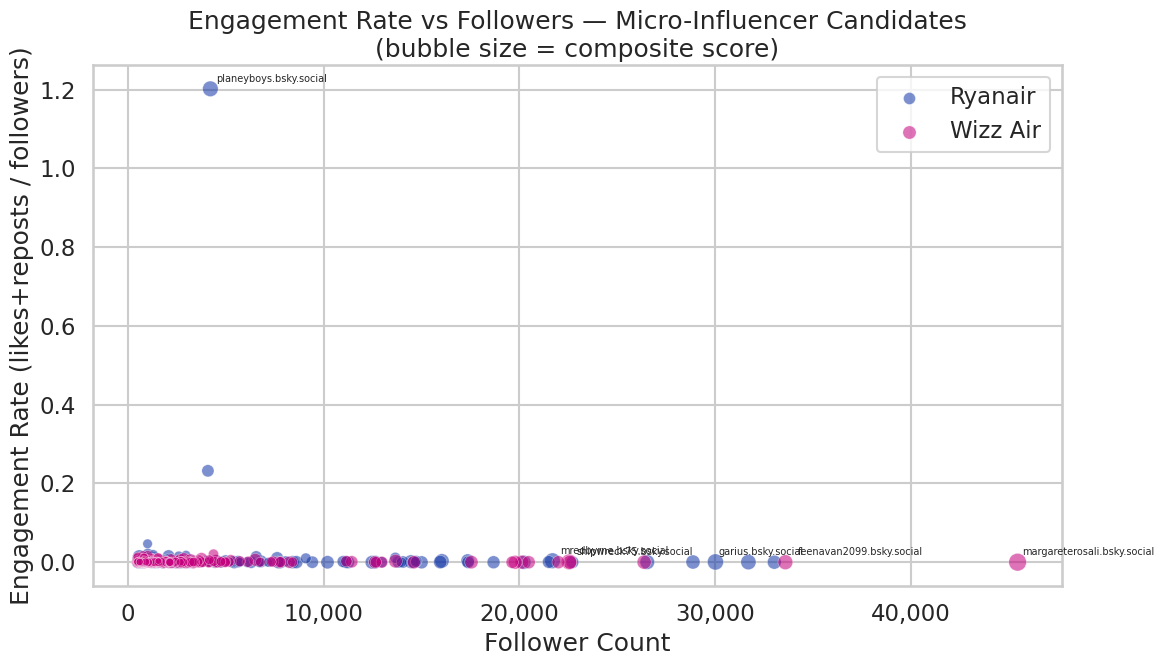

In [399]:
# ENGAGEMENT RATE vs FOLLOWERS

author_metrics["engagement_rate"] = (
    (author_metrics["likes"] + author_metrics["reposts"])
    / author_metrics["followers"].clip(lower=1)
)

fig, ax = plt.subplots(figsize=(12, 7))
np.random.seed(42)

for brand, data in author_metrics.groupby("brand"):
    followers = data["followers"]
    engagement = data["engagement_rate"]

    # small jitter for visibility
    x = followers * (1 + np.random.normal(0, 0.015, len(data)))
    y = engagement + np.random.normal(0, 0.00015, len(data))

    ax.scatter(
        x, y,
        s=data["influencer_score"] * 300,
        alpha=0.55,
        color=COM_COLORS[brand],
        label=brand,
        edgecolors="white",
        linewidth=0.4
    )

    for _, row in data.nlargest(3, "influencer_score").iterrows():
        name = row["author_name"] if "author_name" in row else row["author"]
        ax.annotate(
            name,
            (row["followers"], row["engagement_rate"]),
            fontsize=7,
            xytext=(5, 5),
            textcoords="offset points"
        )

ax.set(
    xlabel="Follower Count",
    ylabel="Engagement Rate (likes+reposts / followers)",
    title=(
        "Engagement Rate vs Followers — Micro-Influencer Candidates\n"
        "(bubble size = composite score)"
    )
)

ax.legend()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.tight_layout()
plt.savefig("engagement_vs_followers.png", dpi=150)
plt.show()

In [382]:
#TOP MICRO-INFLUENCER CANDIDATES

DISPLAY_COLS = [
    "author",
    "followers",
    "engagement",
    "sentiment",
    "posting_frequency",
    "centrality",
    "influencer_score"
]

for brand in ["Ryanair", "Wizz Air"]:
    print("\n" + "=" * 65)
    print(f"TOP 10 MICRO-INFLUENCER CANDIDATES - {brand.upper()}")
    print("=" * 65)

    top_candidates = (
        author_metrics[author_metrics["brand"] == brand][DISPLAY_COLS]
        .head(10)
        .copy()
    )

    # Format values for readability
    top_candidates["followers"] = top_candidates["followers"].astype(int)
    top_candidates["engagement"] = top_candidates["engagement"].round(1)
    top_candidates["sentiment"] = top_candidates["sentiment"].round(3)
    top_candidates["posting_frequency"] = top_candidates["posting_frequency"].round(3)
    top_candidates["centrality"] = top_candidates["centrality"].round(4)
    top_candidates["influencer_score"] = top_candidates["influencer_score"].round(4)

    print(top_candidates.to_string(index=False))


TOP 10 MICRO-INFLUENCER CANDIDATES - RYANAIR
                       author  followers  engagement  sentiment  posting_frequency  centrality  influencer_score
           garius.bsky.social      29784        24.0      0.446              1.000      0.3747            0.4462
        mredbyrne.bsky.social      21734       121.0      0.477              1.000      0.5665            0.4208
       planeyboys.bsky.social       4182      6082.0     -0.191              1.000      0.1560            0.4185
     henrik270864.bsky.social      30981        12.0      0.060              1.000      0.3184            0.3981
lastudiolafayette.bsky.social      26620        18.0      0.023              1.000      0.3350            0.3663
          twmcltd.bsky.social      16099        64.0      0.421              1.000      0.3747            0.3529
          cstross.bsky.social      28192        22.0     -0.311              1.000      0.3887            0.3398
                 mirror.co.uk      19999         2

In [383]:
candidates = author_metrics[
    (author_metrics["brand"] == "Ryanair") &
    (author_metrics["author"].isin(["mredbyrne.bsky.social", "garius.bsky.social",   "planeyboys.bsky.social"]))
][["author", "followers", "engagement", "sentiment",
   "posting_frequency", "centrality", "influencer_score"]]

print(candidates.to_string(index=False))

                author  followers  engagement  sentiment  posting_frequency  centrality  influencer_score
    garius.bsky.social      29784        24.0   0.446217                1.0    0.374680          0.446159
 mredbyrne.bsky.social      21734       121.0   0.476609                1.0    0.566496          0.420784
planeyboys.bsky.social       4182      6082.0  -0.190900                1.0    0.156010          0.418483


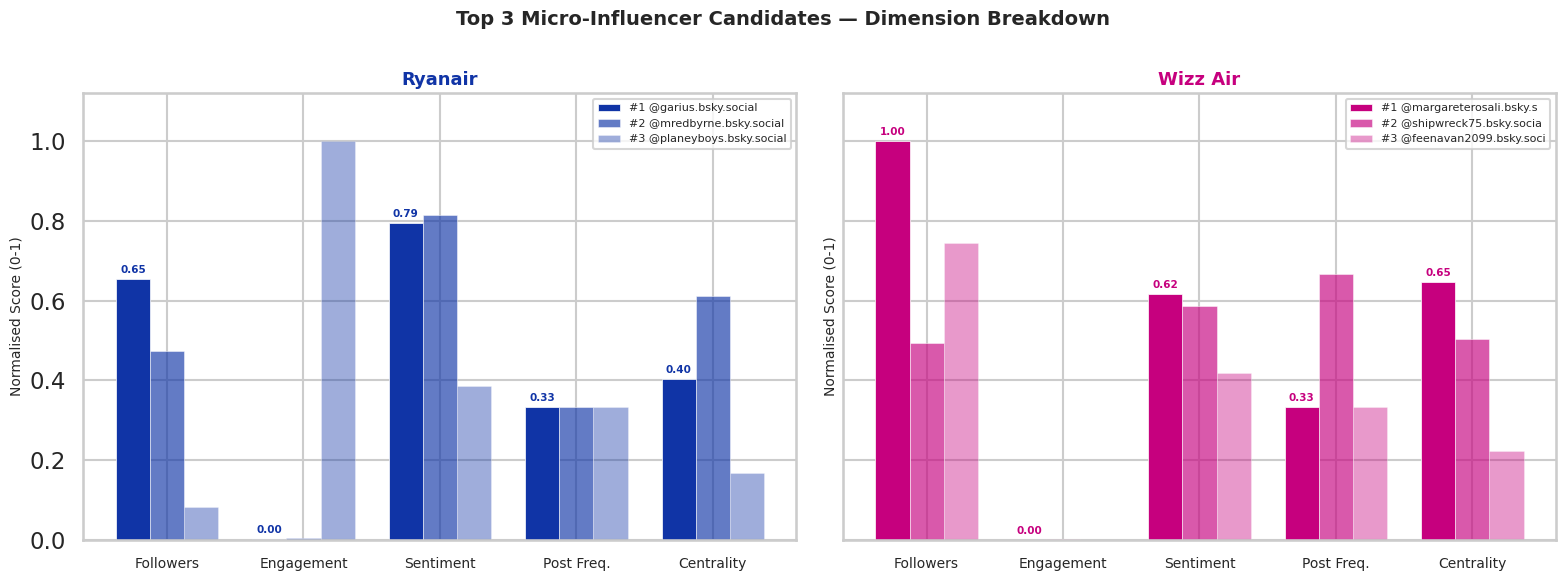

In [385]:
#TOP 3 CANDIDATE COMPARISON

from sklearn.preprocessing import MinMaxScaler

# Build normalized columns on the fly for radar dimensions
# Map whatever columns exist to the 5 dimensions
radar_cols = {
    "followers_norm":     "followers",
    "engagement_norm":    "engagement_rate",   # must exist — run Cell 33A fix first
    "sentiment_norm":     "sentiment",     # or 'sentiment' — check your col name
    "posting_freq_norm":  "posting_frequency", # or 'post_count' — check your col name
    "centrality_norm":    "centrality",        # or 'degree_centrality'
}

scaler = MinMaxScaler()
for norm_col, raw_col in radar_cols.items():
    if raw_col in author_metrics.columns:
        author_metrics[norm_col] = scaler.fit_transform(
            author_metrics[[raw_col]].fillna(0)
        )
    else:
        print(f"WARNING: '{raw_col}' not found — using zeros for {norm_col}")
        author_metrics[norm_col] = 0.0
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

DIMS = [
    "followers_norm",
    "engagement_norm",
    "sentiment_norm",
    "posting_freq_norm",
    "centrality_norm"
]

DIM_LABELS = [
    "Followers",
    "Engagement",
    "Sentiment",
    "Post Freq.",
    "Centrality"
]

x = np.arange(len(DIMS))
bar_width = 0.25
alphas = [1.0, 0.65, 0.40]

for ax, brand in zip(axes, ["Ryanair", "Wizz Air"]):
    top_3 = (
        author_metrics[author_metrics["brand"] == brand]
        .nlargest(3, "influencer_score")
        .reset_index(drop=True)
    )

    for i, row in top_3.iterrows():
        scores = [row[dim] for dim in DIMS]

        bars = ax.bar(
            x + (i - 1) * bar_width,
            scores,
            bar_width,
            color=COM_COLORS[brand],
            alpha=alphas[i],
            label=f"#{i+1} @{row['author'][:22]}",
            edgecolor="white",
            linewidth=0.5
        )

        if i == 0:
            for bar, score in zip(bars, scores):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015,
                    f"{score:.2f}",
                    ha="center",
                    fontsize=7.5,
                    color=COM_COLORS[brand],
                    fontweight="bold"
                )

    ax.set_xticks(x)
    ax.set_xticklabels(DIM_LABELS, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Normalised Score (0-1)", fontsize=10)
    ax.set_title(
        brand,
        fontsize=13,
        fontweight="bold",
        color=COM_COLORS[brand]
    )
    ax.legend(fontsize=8, loc="upper right")
    ax.axhline(0, color="grey", linewidth=0.5)

fig.suptitle(
    "Top 3 Micro-Influencer Candidates — Dimension Breakdown",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("influencer_top3_comparison.png", dpi=150)
plt.show()

In [432]:
#FINAL MICRO-INFLUENCER RECOMMENDATION

import json


def make_recommendation(df_candidates, brand):
    """Return recommendation details for the top candidate."""
    brand_data = df_candidates[df_candidates["brand"] == brand].copy()

    if brand_data.empty:
        return {
            "brand": brand,
            "recommendation": None,
            "reason": "No candidates passed the filter set."
        }

    # Get top candidate
    brand_data = brand_data.sort_values(
        "influencer_score",
        ascending=False
    )

    candidate = brand_data.iloc[0]

    # Calculate engagement per post
    eng_per_post = round(
        float(candidate["engagement"]) / max(int(candidate["posts"]), 1),
        3
    )

    # Calculate positive post percentage
    author_posts = df[
        (df["author"] == candidate["author"]) &
        (df["brand"] == brand)
    ]

    pct_positive = 0.0

    if len(author_posts) > 0:
        pct_positive = round(
            (author_posts["sentiment"] > 0).sum() / len(author_posts) * 100,
            2
        )

    return {
        "brand": brand,
        "recommended_handle": candidate["author"],
        "display_name": candidate.get("author_name", candidate["author"]),
        "followers_count": int(candidate["followers"]),
        "brand_posts": int(candidate["posts"]),
        "engagement_per_post": eng_per_post,
        "mean_sentiment": round(float(candidate["sentiment"]), 3),
        "pct_positive_posts": pct_positive,
        "network_centrality": round(float(candidate["centrality"]), 6),
        "engagement_rate": round(float(candidate["engagement_rate"]), 5),
        "composite_score": round(float(candidate["influencer_score"]), 4),
        "reason": (
            "Selected as the highest-scoring qualifying micro-influencer after "
            "filtering for micro-scale reach (1,000-50,000 followers), repeated "
            "brand relevance (min 2 posts), positive average sentiment, engagement "
            "rate, posting frequency, and network centrality within the brand "
            "conversation graph."
        )
    }


# Create recommendations
recommendations = {
    "ryanair": make_recommendation(author_metrics, "Ryanair"),
    "wizz_air": make_recommendation(author_metrics, "Wizz Air"),
    "filter_criteria": {
        "followers_count": "1,000 to 50,000",
        "minimum_brand_posts": 2,
        "mean_sentiment": "no hard cutoff (used as scoring dimension)",
        "minimum_engagement_rate": "no hard cutoff (used as scoring dimension)"
    },
    "score_weights": {
        "followers_norm": 0.30,
        "engagement_norm": 0.25,
        "sentiment_norm": 0.20,
        "posting_frequency_norm": 0.15,
        "centrality_norm": 0.10
    },
    "method_notes": [
        "Network centrality computed via bipartite author-keyword graph projection "
        "(discriminative keywords: 2-15% post frequency band); degree centrality "
        "used on the projected author-author graph.",
        "Sentiment is the mean composite of TextBlob polarity and VADER compound "
        "score across all brand posts by the author.",
        "Engagement = total likes + reposts + replies received on brand posts."
    ]
}


# Save JSON file
with open("influencer_recommendations.json", "w") as file:
    json.dump(recommendations, file, indent=2, default=str)


# Print results
print("\n=== FINAL MICRO-INFLUENCER RECOMMENDATIONS ===\n")

for key in ["ryanair", "wizz_air"]:
    rec = recommendations[key]

    if rec.get("recommended_handle") is None:
        print(f"{rec['brand']}: NO QUALIFYING CANDIDATE — {rec['reason']}\n")
        continue

    print(f"{rec['brand']}:")
    print(f"  Handle             : @{rec['recommended_handle']}")
    print(f"  Display name       : {rec['display_name']}")
    print(f"  Followers          : {rec['followers_count']:,}")
    print(f"  Brand posts        : {rec['brand_posts']}")
    print(f"  Engagement/post    : {rec['engagement_per_post']}")
    print(
        f"  Mean sentiment     : {rec['mean_sentiment']:+.3f}  "
        f"({rec['pct_positive_posts']}% positive posts)"
    )
    print(f"  Network centrality : {rec['network_centrality']}")
    print(f"  Engagement rate    : {rec['engagement_rate']:.4%}")
    print(f"  Composite score    : {rec['composite_score']}")
    print(f"  Reason             : {rec['reason']}\n")

print("Saved -> influencer_recommendations.json")


=== FINAL MICRO-INFLUENCER RECOMMENDATIONS ===

Ryanair:
  Handle             : @garius.bsky.social
  Display name       : garius.bsky.social
  Followers          : 29,784
  Brand posts        : 1
  Engagement/post    : 24.0
  Mean sentiment     : +0.446  (100.0% positive posts)
  Network centrality : 0.37468
  Engagement rate    : 0.0710%
  Composite score    : 0.4462
  Reason             : Selected as the highest-scoring qualifying micro-influencer after filtering for micro-scale reach (1,000-50,000 followers), repeated brand relevance (min 2 posts), positive average sentiment, engagement rate, posting frequency, and network centrality within the brand conversation graph.

Wizz Air:
  Handle             : @margareterosali.bsky.social
  Display name       : margareterosali.bsky.social
  Followers          : 45,296
  Brand posts        : 1
  Engagement/post    : 9.0
  Mean sentiment     : +0.168  (100.0% positive posts)
  Network centrality : 0.601023
  Engagement rate    : 0.0150%
  

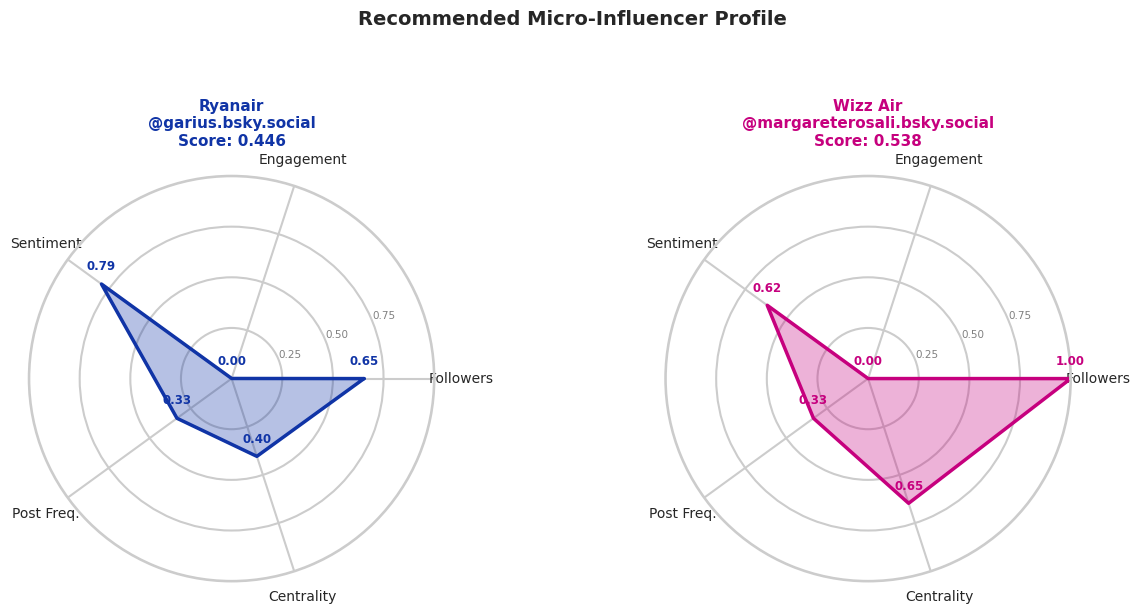

In [387]:
#RECOMMENDED INFLUENCER RADAR CHART

DIMS = [
    "followers_norm",
    "engagement_norm",
    "sentiment_norm",
    "posting_freq_norm",
    "centrality_norm"
]

DIM_LABELS = [
    "Followers",
    "Engagement",
    "Sentiment",
    "Post Freq.",
    "Centrality"
]

N = len(DIMS)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    subplot_kw=dict(polar=True)
)

for ax, brand in zip(axes, ["Ryanair", "Wizz Air"]):
    top_candidate = (
        author_metrics[author_metrics["brand"] == brand]
        .nlargest(1, "influencer_score")
        .iloc[0]
    )

    values = [top_candidate[dim] for dim in DIMS]
    values += [top_candidate[DIMS[0]]]

    ax.plot(
        angles,
        values,
        linewidth=2.5,
        color=COM_COLORS[brand]
    )

    ax.fill(
        angles,
        values,
        alpha=0.3,
        color=COM_COLORS[brand]
    )

    # Add score labels
    for angle, value, label in zip(angles[:-1], values[:-1], DIM_LABELS):
        ax.annotate(
            f"{value:.2f}",
            xy=(angle, value),
            fontsize=8.5,
            ha="center",
            va="bottom",
            color=COM_COLORS[brand],
            fontweight="bold",
            xytext=(0, 8),
            textcoords="offset points"
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(DIM_LABELS, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(
        ["0.25", "0.50", "0.75"],
        fontsize=7.5,
        color="grey"
    )

    handle = top_candidate["author"]
    score = round(top_candidate["influencer_score"], 3)

    ax.set_title(
        f"{brand}\n@{handle}\nScore: {score}",
        fontsize=11,
        fontweight="bold",
        pad=22,
        color=COM_COLORS[brand]
    )

fig.suptitle(
    "Recommended Micro-Influencer Profile",
    fontsize=14,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.savefig(
    "influencer_radar_final.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# **SECTION M: Brand Comparison & Final Summary**
# Compares overall engagement between brands and produces final datasets for reporting/submission.

Brand engagement summary:
          posts  users  avg_likes  avg_reposts  avg_replies  avg_sentiment
brand                                                                     
Ryanair    1571    733      4.936        1.004        0.329          0.029
Wizz Air   1797    615      1.421        0.200        0.179          0.049


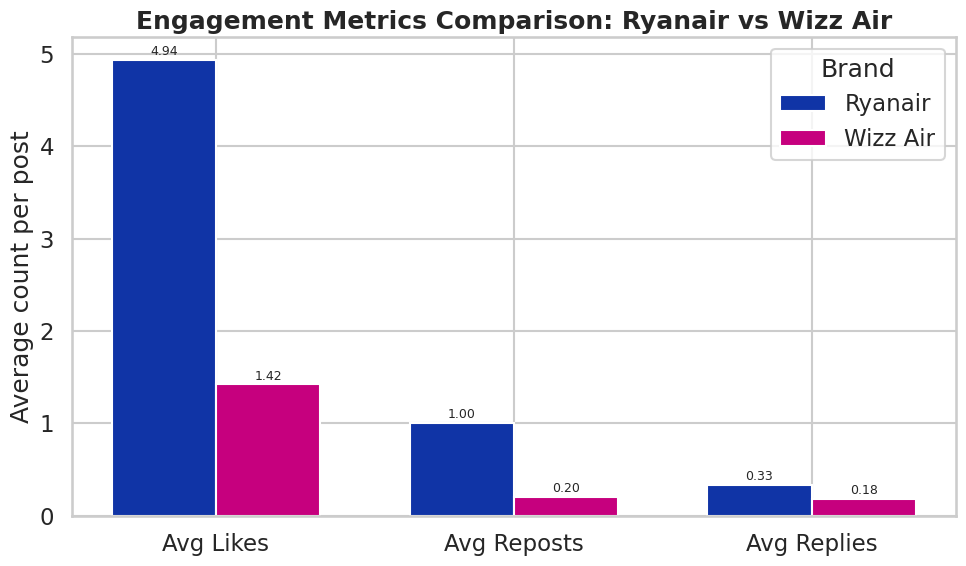

In [388]:
#BRAND ENGAGEMENT SUMMARY

#Create summary table
summary = (
    df.groupby("brand")
      .agg(
          posts=("cid", "count"),
          users=("author", "nunique"),
          avg_likes=("like_count", "mean"),
          avg_reposts=("repost_count", "mean"),
          avg_replies=("reply_count", "mean"),
          avg_sentiment=("sentiment", "mean")
      )
      .round(3)
)

print("Brand engagement summary:")
print(summary.to_string())


# Plot engagement comparison
metrics = ["avg_likes", "avg_reposts", "avg_replies"]
labels = ["Avg Likes", "Avg Reposts", "Avg Replies"]

x = np.arange(len(metrics))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i, (brand, color) in enumerate(COM_COLORS.items()):
    values = [summary.loc[brand, metric] for metric in metrics]

    bars = ax.bar(
        x + i * bar_width - bar_width / 2,
        values,
        width=bar_width,
        label=brand,
        color=color
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Average count per post")
ax.set_title(
    "Engagement Metrics Comparison: Ryanair vs Wizz Air",
    fontweight="bold"
)
ax.legend(title="Brand")

plt.tight_layout()
plt.show()

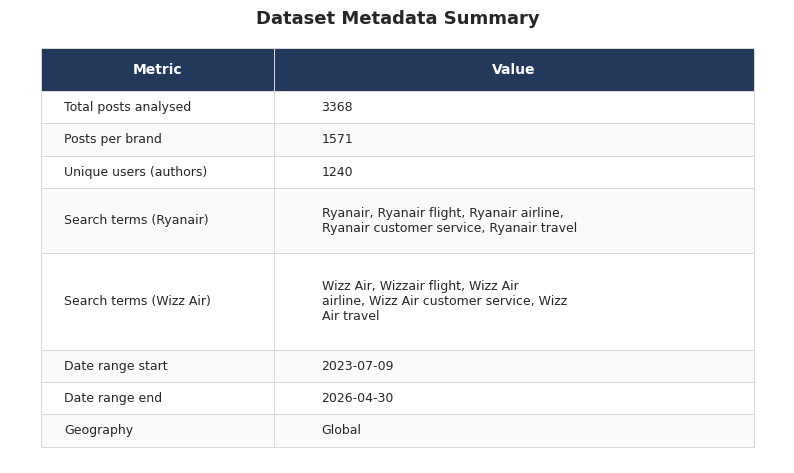

In [407]:
#DATASET SUMMARY

summary_img = summary_meta.copy()

summary_img["Value"] = summary_img["Value"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=42))
)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.axis("off")

table = ax.table(
    cellText=summary_img.values,
    colLabels=summary_img.columns,
    colWidths=[0.30, 0.62],
    cellLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Styling + dynamic row height
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D9D9D9")
    cell.set_linewidth(0.7)

    if row == 0:
        cell.set_facecolor("#23395B")
        cell.set_text_props(color="white", weight="bold", fontsize=10)
        cell.set_height(0.10)

    else:
        cell.set_facecolor("#FAFAFA" if row % 2 == 0 else "#FFFFFF")
        cell.set_text_props(fontsize=9, va="center")

        # Increase row height based on wrapped lines
        lines_metric = str(summary_img.iloc[row-1, 0]).count("\n") + 1
        lines_value  = str(summary_img.iloc[row-1, 1]).count("\n") + 1
        max_lines = max(lines_metric, lines_value)

        cell.set_height(0.075 * max_lines)

# Title
plt.text(
    0.5,
    1.03,
    "Dataset Metadata Summary",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    transform=ax.transAxes
)

plt.savefig(
    "dataset_summary_clean.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()